1. Otomoto Price Prediction Model - Training Pipeline
--------------------------------------------------
This notebook handles the end-to-end process of training the car valuation model:
1. Environment & Configuration
2. Feature Engineering & Cleaning
3. Model Training (XGBoost/CatBoost/AutoGluon)
4. Evaluation & Export



In [1]:
import warnings
import os

# Filter TqdmWarnings before importing libraries that use them (like SHAP/CatBoost)
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except ImportError:
    # If tqdm isn't installed or TqdmWarning isn't found, just ignore it safely
    pass

# Suppress other warnings to keep the notebook output clean
warnings.filterwarnings('ignore')

# ==========================================
# 1. IMPORTS
# ==========================================

# Standard Library
import os
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, List

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap  # Explainable AI (SHAP values)

# Machine Learning - Utilities
import joblib
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibrationDisplay 

import warnings
from tqdm import TqdmWarning

# This stops the "IProgress not found" warning from appearing
warnings.filterwarnings("ignore", category=TqdmWarning)

# Machine Learning - Metrics
# Note: Added Regression metrics (MAE, R2) since 'price' is a continuous variable.
# Kept Classification metrics (ROC/AUC) in case you convert this to a "Good Deal" classifier later.
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score,
    roc_auc_score, 
    classification_report, 
    confusion_matrix
)

# Machine Learning - Models
import xgboost as xgb
import catboost as cb

# ==========================================
# 2. GLOBAL SETTINGS
# ==========================================

# Suppress warnings to keep the notebook output clean
warnings.filterwarnings('ignore')

# Pandas Display Options: Ensure we can see all columns in the Dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Visualization Style: Use 'ggplot' for a professional grid look
plt.style.use('ggplot')
sns.set_context('notebook', font_scale=1.1)

# ==========================================
# 3. CONFIGURATION (Single Source of Truth)
# ==========================================

@dataclass
class Config:
    """
    Central Configuration Class.
    Allows for easy adjustments of paths and hyperparameters without modifying logic code.
    """
    
    # --- DATA PATHS ---
    # Input file: Ensure this file exists in the 'data/' folder
    RAW_DATA_PATH: str = "data/raw_data.csv" 
    
    # Generated files: These will be created by the pipeline
    TRAIN_PATH: str = "data/train.csv"
    TEST_PATH: str = "data/test.csv"
    OUTPUT_PATH: str = "saved_models/"
    
    # --- MODEL SCHEMA ---
    # The variable we want to predict
    TARGET: str = "price"
    
    # Columns to exclude from training (IDs, Dates, Metadata)
    ID_COLS: Tuple[str, ...] = (
        "ad_id", "url", "title", 
        "createdAt", "current_date", "page_number"
    )
    
    # --- VALIDATION STRATEGY ---
    N_FOLDS: int = 5            # Number of Cross-Validation Folds
    RANDOM_SEED: int = 42       # Seed for reproducibility (42 is standard)
    TEST_SIZE: float = 0.2      # 20% of data reserved for final testing
    
    # --- MODEL HYPERPARAMETERS ---
    EARLY_STOPPING: int = 50    # Stop training if metric doesn't improve for 50 rounds
    
    # Hardware Acceleration
    # Use "cuda" for NVIDIA GPUs, "mps" for Mac M1/M2, or "cpu" for standard processors
    DEVICE: str = "cuda"

# Initialize the configuration object
config = Config()

# ==========================================
# 4. ENVIRONMENT INITIALIZATION
# ==========================================

# 1. Enforce Reproducibility
# Setting the seed ensures that every run produces the exact same split and results.
np.random.seed(config.RANDOM_SEED)

# 2. Create Directory Structure
# Automatically create 'data/' and 'models/' folders if they don't exist.
Path(config.OUTPUT_PATH).mkdir(parents=True, exist_ok=True)
Path("data").mkdir(parents=True, exist_ok=True)

# 3. Validation Feedback
print("-" * 50)
print(f"✅ Configuration Loaded Successfully.")
print(f"📂 Model Output Directory: {os.path.abspath(config.OUTPUT_PATH)}")

# Check if input data exists
if os.path.exists(config.RAW_DATA_PATH):
    print(f"📊 Raw Data Found:       {config.RAW_DATA_PATH}")
else:
    print(f"⚠️  WARNING: Raw data file not found at '{config.RAW_DATA_PATH}'")
    print(f"    Please place your .csv file in the 'data/' folder before proceeding.")
print("-" * 50)

--------------------------------------------------
✅ Configuration Loaded Successfully.
📂 Model Output Directory: c:\Users\pawel\Documents\Python_projects\otomoto\ML_car_valuation_otomoto\saved_models
📊 Raw Data Found:       data/raw_data.csv
--------------------------------------------------


1.5 Otomoto Data Pre-processing Pipeline
------------------------------------
Purpose: Transforms raw scraped data into a clean, machine-learning-ready format.
Key Capabilities:
1. Automatic Translation (Polish -> English)
2. Geo-Spatial Feature Engineering (Distance to Capital)
3. Smart Outlier Detection (Isolation Forest) with "Safety Report"
4. Numeric & Categorical Standardization

In [2]:
# ==========================================
# 1. IMPORTS & CONFIGURATION
# ==========================================
import os
import re
import numpy as np
import pandas as pd
from deep_translator import GoogleTranslator
from sklearn.ensemble import IsolationForest 
from typing import List, Optional

# --- DOMAIN KNOWLEDGE CONFIGURATION ---
COLUMNS_TO_TRANSLATE: List[str] = [
    'body_type', 'color', 'country_origin', 'fuel_type', 
    'gearbox', 'new_used', 'seller_type', 'transmission'
]

NUMERIC_HINTS: List[str] = [
    'power', 'mileage', 'year', 'capacity', 'doors', 'seats', 'cylinders', 'engine'
]

COLS_TO_FILL_MISSING: List[str] = [
    'body_type', 'brand', 'city', 'color', 'country_origin', 
    'fuel_type', 'gearbox', 'generation', 'model', 'new_used', 
    'price_currency', 'region', 'seller_type', 'transmission', 
    'version', 'region_grid'
]

REF_LAT = 52.2297 
REF_LON = 21.0122

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def haversine_distance(lat1: pd.Series, lon1: pd.Series, lat2: float, lon2: float) -> pd.Series:
    """Vectorized Haversine formula to calculate distance in km."""
    R = 6371 
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

def translate_unique_values(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    """Translates only unique values in a column to save API calls."""
    if col_name not in df.columns: return df
    uniques = df[col_name].dropna().unique().tolist()
    text_uniques = [str(x) for x in uniques if not str(x).isnumeric() and str(x) != "Missing"]
    
    if not text_uniques: return df

    print(f"   🌍 Translating {len(text_uniques)} terms in '{col_name}'...")
    translator = GoogleTranslator(source='pl', target='en')
    map_dict = {}
    for term in text_uniques:
        try:
            map_dict[term] = term if not term.strip() else translator.translate(term)
        except:
            map_dict[term] = term
    df[col_name] = df[col_name].map(map_dict).fillna(df[col_name])
    return df

def clean_currency_vectorized(series: pd.Series) -> pd.Series:
    # UPDATED: Handle European commas before regex
    clean = series.astype(str).str.replace(',', '.', regex=False)
    clean = clean.str.replace(r'[^\d.]', '', regex=True)
    return pd.to_numeric(clean, errors='coerce')

def extract_year_vectorized(series: pd.Series) -> pd.Series:
    return series.astype(str).str.extract(r'\b((?:19|20)\d{2})\b')[0].astype(float)

# ==========================================
# 3. MAIN PRE-PROCESSING PIPELINE
# ==========================================

if os.path.exists(config.RAW_DATA_PATH):
    print(f"📂 Loading raw data from: {config.RAW_DATA_PATH}")
    df_raw = pd.read_csv(config.RAW_DATA_PATH, low_memory=False)
    
    # 1. Standardize Coords
    df_raw.rename(columns={'lat': 'latitude', 'lon': 'longitude'}, inplace=True)
    
    # 2. Clean Headers
    if config.TARGET in df_raw.columns:
        df_raw = df_raw[df_raw[config.TARGET] != config.TARGET] 

    # 3. Drop Unwanted
    drop_list = ["subregion", "ad_id", "user_id", "url", "title", "createdAt", "page_number", "seller_since", "seller_since2"]
    
    # 4. Engineer Seller Info
    print("🔨 Engineering: Merging seller info...")
    has_s1, has_s2 = 'seller_since' in df_raw.columns, 'seller_since2' in df_raw.columns
    if has_s1 or has_s2:
        combined = df_raw['seller_since'].fillna('').astype(str) if has_s1 else ""
        if has_s2: combined += " " + df_raw['seller_since2'].fillna('').astype(str)
        df_raw['seller_since_year'] = extract_year_vectorized(combined)

    df_raw.drop(columns=[c for c in drop_list if c in df_raw.columns], inplace=True)

    # 5. Location Features
    print("📍 Engineering: Location Features...")
    if 'latitude' in df_raw.columns and 'longitude' in df_raw.columns:
        # Force numeric conversion for coords with comma handling
        df_raw['latitude'] = pd.to_numeric(df_raw['latitude'].astype(str).str.replace(',', '.'), errors='coerce')
        df_raw['longitude'] = pd.to_numeric(df_raw['longitude'].astype(str).str.replace(',', '.'), errors='coerce')
        
        df_raw['dist_to_warsaw'] = haversine_distance(df_raw['latitude'], df_raw['longitude'], REF_LAT, REF_LON)
        df_raw['region_grid'] = df_raw['latitude'].round(1).astype(str) + '_' + df_raw['longitude'].round(1).astype(str)
        print("   ✅ Added 'dist_to_warsaw' and 'region_grid'")

    # 6. Clean Numeric Columns
    print("🔧 Cleaning: Rescuing numeric columns...")
    for col in df_raw.columns:
        if any(h in col.lower() for h in NUMERIC_HINTS) and df_raw[col].dtype == 'object':
            # Handle commas globally
            df_raw[col] = df_raw[col].astype(str).str.replace(',', '.', regex=False)
            df_raw[col] = df_raw[col].str.replace(r'[^\d.]', '', regex=True)
            df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    # 7. Clean Target
    print(f"💰 Cleaning Target: '{config.TARGET}'...")
    if config.TARGET in df_raw.columns:
        df_raw[config.TARGET] = clean_currency_vectorized(df_raw[config.TARGET])
        df_raw = df_raw.dropna(subset=[config.TARGET])

    # =========================================================
    # 7.5 ULTIMATE SHIELDED ISOLATION FOREST (v3)
    # =========================================================
    print("🌲 Running Advanced Outlier Detection...")
    from sklearn.preprocessing import OrdinalEncoder

    # --- 1. THE JUNK SCRUB (Pattern Detection) ---
    luxury_brands = [
        'Lamborghini', 'Rolls-Royce', 'Ferrari', 'Bentley', 'McLaren', 
        'Aston Martin', 'Porsche', 'Maybach', 'Maserati', 'Lotus', 'Cadillac', 'Land Rover'
    ]
    
    junk_pattern_mask = (
        (df_raw[config.TARGET] >= 5555555) & 
        (~df_raw['brand'].isin(luxury_brands))
    )
    scrubbed_indices = df_raw[junk_pattern_mask].index

    # --- 2. CONFIGURATION FOR FOREST ---
    protected_keywords = [
        'amg', 'klasa g', 'g-class', 'slr', 'klasa s', 's-class', '911', 'r8', 
        'defender', 'viper', 'alpina', 'escalade', 'xb7', 'taycan', 'panamera',
        'q3', 'q7', 'q8', 'rs6', 'rs7', 'gle', 'gls', 's8'
    ]
    PRICE_SHIELD = 400_000 

    # --- 3. PREP DATA FOR FOREST ---
    iso_cols = [config.TARGET, 'year', 'mileage', 'power', 'engine_capacity', 'brand', 'model']
    valid_iso = [c for c in iso_cols if c in df_raw.columns]
    
    # Secure copy for Forest
    scan_data = df_raw[valid_iso].dropna().copy()
    
    if len(scan_data) > 100:
        # --- FIX: Loop over ALL numeric columns in scan_data to handle 'year', 'capacity' etc. ---
        # Identify non-text columns
        numeric_scan_cols = [c for c in scan_data.columns if c not in ['brand', 'model']]
        
        for col in numeric_scan_cols:
            # Force String -> Replace Comma -> Numeric -> FillNA(0)
            # This fixes '1969,00' in engine_capacity or year causing crashes
            scan_data[col] = pd.to_numeric(
                scan_data[col].astype(str).str.replace(',', '.', regex=False), 
                errors='coerce'
            ).fillna(0)

        # Log Transform (Safety clipped)
        for col in [config.TARGET, 'mileage', 'power']:
            if col in scan_data.columns:
                scan_data[col] = np.log1p(scan_data[col])

        # ENCODE categories
        encoder = OrdinalEncoder()
        cat_cols = ['brand', 'model']
        present_cats = [c for c in cat_cols if c in scan_data.columns]
        scan_data[present_cats] = encoder.fit_transform(scan_data[present_cats].astype(str))

        # --- 4. RUN FOREST ---
        clf = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
        preds = clf.fit_predict(scan_data)
        if_outlier_indices = scan_data.index[preds == -1]
        
        # --- 5. THE MULTI-LAYER SHIELD (Safe Version) ---
        final_to_delete = list(scrubbed_indices)
        
        # Helper to prevent TypeErrors inside the loop
        def safe_float(val):
            try: return float(val)
            except: return 0.0

        for i in if_outlier_indices:
            if i in final_to_delete: continue
            
            row = df_raw.loc[i]
            brand_val = str(row.get('brand', '')).lower()
            model_val = str(row.get('model', '')).lower()
            full_name = f"{brand_val} {model_val}"
            
            # SAFE EXTRACT: Explicitly cast to float to prevent 'str' < 'int' crash
            price_val = safe_float(row.get(config.TARGET))
            mileage_val = safe_float(row.get('mileage'))
            year_val = safe_float(row.get('year'))
            
            # SHIELD LOGIC
            is_luxury_brand = any(lb.lower() in brand_val for lb in luxury_brands)
            is_high_end_model = any(k in full_name for k in protected_keywords)
            is_expensive = price_val >= PRICE_SHIELD
            is_new_car = mileage_val < 100
            is_classic = year_val < 1980
            
            if not (is_luxury_brand or is_high_end_model or is_expensive or is_new_car or is_classic):
                final_to_delete.append(i)
        
        outliers = df_raw.loc[final_to_delete]
        
        print(f"\n🛡️  SHIELD REPORT:")
        print(f"   - Deleted {len(scrubbed_indices)} obvious placeholders.")
        print(f"   - Forest flagged {len(if_outlier_indices)} outliers.")
        print(f"   - Final action: Deleting {len(final_to_delete)} rows.")

        if not outliers.empty:
            show_cols = [c for c in ['brand', 'model', 'year', config.TARGET, 'mileage'] if c in df_raw.columns]
            print("\n🗑️  CONFIRMED JUNK (Top Prices):")
            display(outliers[show_cols].sort_values(config.TARGET, ascending=False).head(5))

        # 6. EXECUTE DELETE
        df_raw = df_raw.drop(index=final_to_delete)

    # 8. Fill Missing Categories
    print(f"🔧 Cleaning: Filling missing values...")
    for col in COLS_TO_FILL_MISSING:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].fillna("Missing").astype(str).replace(r'^\s*$', 'Missing', regex=True)

    # 9. Translate
    print("🤖 Processing: Dynamic Translation...")
    for col in COLUMNS_TO_TRANSLATE:
        df_raw = translate_unique_values(df_raw, col)
    
    # 10. Deduplicate
    df_raw = df_raw.drop_duplicates()
    
    print("-" * 50)
    print(f"✨ PROCESSING COMPLETE. Memory contains {len(df_raw)} clean rows.")
    print("👉 NEXT STEP: Run Script 1.6 to save 'train.csv' and 'test.csv'.")
    print("-" * 50)

else:
    print(f"⚠️ Critical Error: Raw file not found at {config.RAW_DATA_PATH}")

📂 Loading raw data from: data/raw_data.csv
🔨 Engineering: Merging seller info...
📍 Engineering: Location Features...
   ✅ Added 'dist_to_warsaw' and 'region_grid'
🔧 Cleaning: Rescuing numeric columns...
💰 Cleaning Target: 'price'...
🌲 Running Advanced Outlier Detection...

🛡️  SHIELD REPORT:
   - Deleted 5 obvious placeholders.
   - Forest flagged 2232 outliers.
   - Final action: Deleting 573 rows.

🗑️  CONFIRMED JUNK (Top Prices):


,brand,model,year,price,mileage
50096,Volkswagen,Golf,2014,9999999.0,126000.0
125270,Renault,Megane,2018,9999999.0,145000.0
135848,Ford,Mondeo,2008,9999999.0,205813.0
187930,Volkswagen,Golf,2014,9999999.0,150000.0
191360,Audi,A4 Avant,2015,5555555.0,254331.0


🔧 Cleaning: Filling missing values...
🤖 Processing: Dynamic Translation...
   🌍 Translating 9 terms in 'body_type'...
   🌍 Translating 17 terms in 'color'...
   🌍 Translating 39 terms in 'country_origin'...
   🌍 Translating 8 terms in 'fuel_type'...
   🌍 Translating 2 terms in 'gearbox'...
   🌍 Translating 2 terms in 'new_used'...
   🌍 Translating 2 terms in 'seller_type'...
   🌍 Translating 5 terms in 'transmission'...
--------------------------------------------------
✨ PROCESSING COMPLETE. Memory contains 226029 clean rows.
👉 NEXT STEP: Run Script 1.6 to save 'train.csv' and 'test.csv'.
--------------------------------------------------


1.6 STRATEGIC DATA SPLITTING & EXPORT
Purpose: Prevents "Data Leakage" by separating data into two strictly independent sets.
1. Training Set (train_df): The model sees ONLY this data during learning.
2. Holdout Set (test_df): The model NEVER sees this. It is locked in a vault and used only once at the very end to judge true performance.

In [3]:
from sklearn.model_selection import train_test_split
import sys

# ==========================================
# 1. DEPENDENCY CHECK
# ==========================================
# We ensure the clean data exists in memory before proceeding.
if 'df_raw' not in locals():
    print("⛔ CRITICAL ERROR: 'df_raw' not found in memory.")
    print("   Please run Script 1.5 (Data Processing) first.")
else:
    print("✂️  Initiating Train/Test Split...")

    # ==========================================
    # 2. PERFORM THE SPLIT
    # ==========================================
    # We use a fixed 'random_state' (Seed) to ensure that if we run this script 
    # 10 times, we get the exact same split every time. This is crucial for 
    # reproducible science.
    train_df, test_df = train_test_split(
        df_raw, 
        test_size=config.TEST_SIZE,     # Defined in Config (usually 0.1 or 0.2)
        random_state=config.RANDOM_SEED # Defined in Config (e.g., 42)
    )

    # ==========================================
    # 3. EXPORT TO DISK
    # ==========================================
    print(f"💾 Writing files to disk...")
    
    # Save Training Data
    # index=False prevents pandas from adding an annoying generic index column (0,1,2...)
    train_df.to_csv(config.TRAIN_PATH, index=False)
    
    # Save Holdout Data
    test_df.to_csv(config.TEST_PATH, index=False)
    
    # ==========================================
    # 4. FINAL STATUS REPORT
    # ==========================================
    print("-" * 50)
    print(f"✅ DATA PIPELINE SUCCESSFUL.")
    print("-" * 50)
    print(f"   📂 Training Set Saved: {config.TRAIN_PATH}")
    print(f"      Rows: {len(train_df):,}  |  Columns: {train_df.shape[1]}")
    print(f"      Use this file to TRAIN your models.")
    print("-" * 50)
    print(f"   📂 Holdout Set Saved:  {config.TEST_PATH}")
    print(f"      Rows: {len(test_df):,}  |  Columns: {test_df.shape[1]}")
    print(f"      Use this file ONLY for final auditing (The Stress Test).")
    print("-" * 50)
    
    # Optional: Clean up memory (delete the big raw file now that we have splits)
    # del df_raw

✂️  Initiating Train/Test Split...
💾 Writing files to disk...
--------------------------------------------------
✅ DATA PIPELINE SUCCESSFUL.
--------------------------------------------------
   📂 Training Set Saved: data/train.csv
      Rows: 180,823  |  Columns: 36
      Use this file to TRAIN your models.
--------------------------------------------------
   📂 Holdout Set Saved:  data/test.csv
      Rows: 45,206  |  Columns: 36
      Use this file ONLY for final auditing (The Stress Test).
--------------------------------------------------


2. Otomoto Evaluation & Visualization Utilities
--------------------------------------------
These functions are designed for REGRESSION tasks (predicting continuous prices).
Includes:
1. Metrics Calculation (MAE, RMSE, R2)
2. Actual vs. Predicted Plots
3. Error Distribution Histograms

In [4]:
# ==========================================
# 1. IMPORTS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 2. EVALUATION METRICS
# ==========================================

def evaluate_model(y_true: pd.Series, y_pred: np.array, model_name: str = "Model") -> dict:
    """
    Calculates standard regression metrics to judge model accuracy.
    
    Args:
        y_true: The actual prices (ground truth).
        y_pred: The predicted prices from the model.
        model_name: Label for printing.
        
    Returns:
        Dictionary containing MAE, RMSE, R2, and MAPE.
    """
    # 1. Calculate Metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # 2. Calculate Percentage Error (MAPE)
    # Handling division by zero safety
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    # 3. Print Professional Report
    print(f"--- 📊 {model_name} Performance Report ---")
    print(f"   🔹 R² Score:      {r2:.4f}  (Higher is better, max 1.0)")
    print(f"   🔹 MAE (Avg Err): {mae:,.0f} PLN  (Average miss in PLN)")
    print(f"   🔹 RMSE:          {rmse:,.0f} PLN  (Penalizes large errors)")
    print(f"   🔹 MAPE:          {mape:.2f}%     (Average miss in %)")
    print("-" * 45)
    
    return {
        "model": model_name, 
        "mae": mae, 
        "rmse": rmse, 
        "r2": r2, 
        "mape": mape
    }

# ==========================================
# 3. VISUALIZATION FUNCTIONS
# ==========================================

def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted Prices"):
    """
    Scatter plot to visually assess how well predictions match reality.
    The red line represents perfect prediction.
    """
    plt.figure(figsize=(10, 6))
    
    # Scatter plot of data points
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.3, color='blue', edgecolor=None)
    
    # Perfect Prediction Line (x=y)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')
    
    plt.title(title, fontsize=14)
    plt.xlabel("Actual Price (PLN)", fontsize=12)
    plt.ylabel("Predicted Price (PLN)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Format axes with thousands separator (e.g. 100,000)
    current_values = plt.gca().get_xticks()
    plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])
    current_values_y = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values_y])
    
    plt.tight_layout()
    plt.show()

def plot_error_distribution(y_true, y_pred):
    """
    Histogram of Prediction Errors.
    Ideally, this should look like a Bell Curve (Normal Distribution) centered at 0.
    """
    errors = y_pred - y_true
    
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True, bins=50, color='purple', alpha=0.6)
    
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label="Zero Error")
    
    plt.title("Distribution of Prediction Errors (Residuals)", fontsize=14)
    plt.xlabel("Prediction Error (PLN) -> [Positive = Overpriced, Negative = Underpriced]", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Limit x-axis to remove extreme outliers for better visibility (optional)
    # plt.xlim(-50000, 50000) 
    
    plt.tight_layout()
    plt.show()

print("✅ Helper functions defined (Regression Mode)")

✅ Helper functions defined (Regression Mode)


3. Otomoto Data Loader & Feature Schema Definition
-----------------------------------------------
This module loads the pre-split CSV files and prepares the feature sets (X) and targets (y).

CRITICAL OPERATION: Categorical Alignment
It enforces that the Validation Set (Holdout) uses the EXACT same category dictionary
as the Training Set. This prevents "Unknown Category" errors during model inference.

In [5]:
# ==========================================
# 1. DEPENDENCY CHECK
# ==========================================
import sys
import pandas as pd
import numpy as np

if 'config' not in locals():
    sys.exit("⛔ Config object not found! Please run Cell 1 first.")

# ==========================================
# 2. DATA LOADING
# ==========================================
print(f"📂 Loading datasets...")
try:
    df_train = pd.read_csv(config.TRAIN_PATH)
    df_holdout = pd.read_csv(config.TEST_PATH)
except FileNotFoundError as e:
    sys.exit(f"❌ Error: Could not find data files. Did you run Cell 1.5? ({e})")

# ==========================================
# 3. FEATURE SEPARATION
# ==========================================

# Define columns to remove (Target + IDs)
# We use set intersection to avoid errors if a column is missing
cols_to_remove = set([config.TARGET] + list(config.ID_COLS))
existing_drop_cols = [c for c in df_train.columns if c in cols_to_remove]

print(f"🛑 Dropping Non-Feature Columns: {existing_drop_cols}")

# Create Feature Matrices (X) and Target Vectors (y)
X_train_full = df_train.drop(columns=existing_drop_cols, errors='ignore')
y_train_full = df_train[config.TARGET]

X_holdout = df_holdout.drop(columns=existing_drop_cols, errors='ignore')
y_holdout = df_holdout[config.TARGET]

# ==========================================
# 4. TYPE MANAGEMENT & ALIGNMENT
# ==========================================

# Identify feature types automatically
cat_features = X_train_full.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_features = X_train_full.select_dtypes(include=[np.number]).columns.tolist()

print("🔗 Aligning Categorical Features...")

for col in cat_features:
    # A. Convert Training data to 'category' dtype
    X_train_full[col] = X_train_full[col].astype('category')
    
    # B. CRITICAL: Force Holdout to use Train's categories
    # This ensures that if the Holdout set has a rare value (e.g., "Pink") 
    # that wasn't in Train, it gets turned into NaN/Unknown instead of crashing the model.
    train_categories = X_train_full[col].cat.categories
    
    X_holdout[col] = X_holdout[col].astype('category')
    X_holdout[col] = pd.Categorical(
        X_holdout[col], 
        categories=train_categories
    )

# ==========================================
# 5. DATASET SUMMARY
# ==========================================

print("-" * 50)
print(f"📊 Training Data: {X_train_full.shape[0]:,} rows, {X_train_full.shape[1]} features")
print(f"🧪 Holdout Data:  {X_holdout.shape[0]:,} rows, {X_holdout.shape[1]} features")
print("-" * 50)

print(f"🔢 NUMERICAL Features ({len(num_features)}):")
print(f"   {num_features}")
print("-" * 50)

print(f"🔠 CATEGORICAL Features ({len(cat_features)}):")
print(f"   {cat_features}")
print("-" * 50)

print("✅ Data Loaded, Aligned, and Ready for Training.")

📂 Loading datasets...
🛑 Dropping Non-Feature Columns: ['price']
🔗 Aligning Categorical Features...
--------------------------------------------------
📊 Training Data: 180,823 rows, 35 features
🧪 Holdout Data:  45,206 rows, 35 features
--------------------------------------------------
🔢 NUMERICAL Features (19):
   ['co2_emissions', 'damaged', 'door_count', 'engine_capacity', 'engine_power', 'extra_urban_consumption', 'has_registration', 'has_vin', 'is_imported_car', 'latitude', 'longitude', 'mileage', 'no_accident', 'nr_seats', 'service_record', 'urban_consumption', 'year', 'seller_since_year', 'dist_to_warsaw']
--------------------------------------------------
🔠 CATEGORICAL Features (16):
   ['body_type', 'brand', 'city', 'color', 'country_origin', 'fuel_type', 'gearbox', 'generation', 'model', 'new_used', 'price_currency', 'region', 'seller_type', 'transmission', 'version', 'region_grid']
--------------------------------------------------
✅ Data Loaded, Aligned, and Ready for Traini

3.5 Otomoto Feature Selection (Scout Model)
---------------------------------------
This module performs two critical optimizations:
1. Multicollinearity Removal: Drops features that are >98% correlated (redundant).
2. Noise Reduction: Trains a lightweight XGBoost "Scout" to find and remove features with 0 importance.

Goal: Reduce model size and training time without losing accuracy.

🕵️ Starting Price Driver Analysis...

📉 MANUAL ADJUSTMENT: Dropping 11 features...
   Targets: ['co2_emissions', 'has_vin', 'nr_seats', 'longitude', 'latitude', 'dist_to_warsaw', 'door_count', 'region_grid', 'seller_type', 'extra_urban_consumption', 'urban_consumption']
   ✅ Drop complete. Active features remaining: 24

🔧 Encoding text features for stability...
   ✅ Successfully encoded 14 categorical features.

🚀 Training 'Scout' Model (XGBoost) on ALL features...

📊 FEATURE IMPORTANCE RANKING (6 Decimal Precision)


,Feature,Importance
7,engine_power,0.180517
22,year,0.164943
20,transmission,0.139206
13,mileage,0.121720
6,engine_capacity,0.068423
16,no_accident,0.045060
12,is_imported_car,0.043860
9,gearbox,0.043544
1,brand,0.029448
5,damaged,0.027186


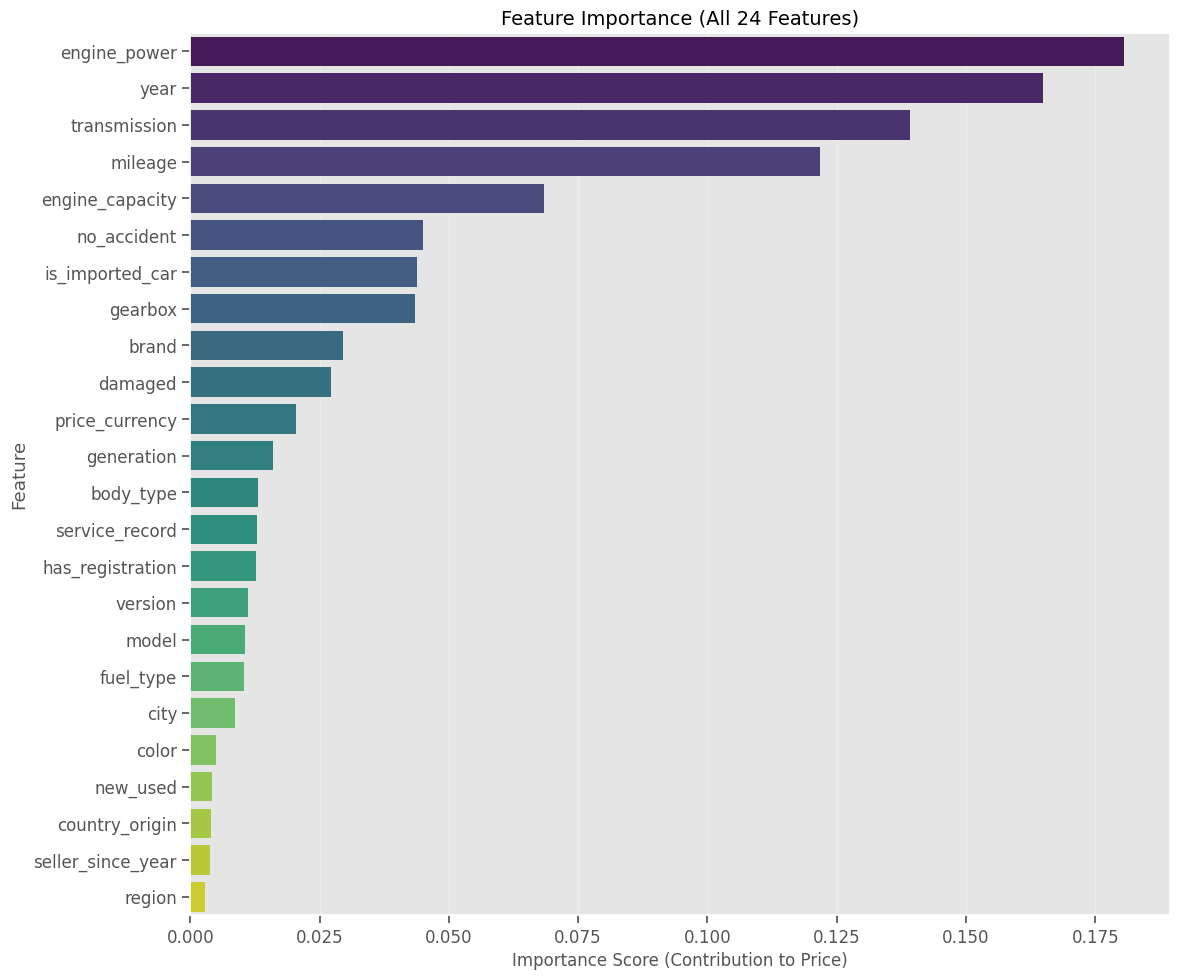

🗑️ Noise Reduction: Found 0 features with 0.000000 importance.

✨ No pruning required.

📋 FINAL FEATURE AUDIT REPORT

✅ NO FEATURES WERE REMOVED (Post-analysis).

✨ FINAL ACTIVE FEATURES (24):

   🔠 Categorical (14):
      body_type, brand, city, color, country_origin, fuel_type, gearbox, generation, model, new_used, price_currency, region, transmission, version

   🔢 Numerical (10):
      damaged, engine_capacity, engine_power, has_registration, is_imported_car, mileage, no_accident, seller_since_year, service_record, year


In [6]:
# ==========================================
# 1. DEPENDENCY & SAFETY CHECK
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Check if data exists in memory
if 'X_train_full' not in locals():
    raise SystemExit("⛔ Data not found! Please run the previous data loading/splitting cell first.")

print("🕵️ Starting Price Driver Analysis...")

# ==========================================
# 1.5 MANUAL FEATURE ADJUSTMENT (Pre-Analysis)
# ==========================================
# We remove these features NOW so they don't affect the Scout Model or future steps.

# A. Define specific columns to drop
manual_drop_list = [
    'seller_since', 
    'co2_emissions', 
    'has_vin', 
    'nr_seats', 
    'longitude', 
    'latitude', 
    'dist_to_warsaw', 
    'door_count',
    'region_grid',
    'seller_type'
]

# B. Drop "Consumption" related fields dynamically
# We look at X_train_full columns to find any containing "consumption"
consumption_cols = [col for col in X_train_full.columns if 'consumption' in col.lower()]
manual_drop_list.extend(consumption_cols)

# Filter the list to only include columns that actually exist in our data
cols_to_drop_now = [col for col in manual_drop_list if col in X_train_full.columns]

if cols_to_drop_now:
    print(f"\n📉 MANUAL ADJUSTMENT: Dropping {len(cols_to_drop_now)} features...")
    print(f"   Targets: {cols_to_drop_now}")

    # Drop from Training Data
    X_train_full = X_train_full.drop(columns=cols_to_drop_now)
    # Drop from Holdout Data (to keep them in sync)
    X_holdout = X_holdout.drop(columns=cols_to_drop_now)
    
    print(f"   ✅ Drop complete. Active features remaining: {X_train_full.shape[1]}")
else:
    print("\nℹ️ Manual Adjustment: No matching columns found to drop (already removed?).")

# ==========================================
# 2. ROBUST DATA PREPARATION
# ==========================================
# Create a temporary copy for the Scout Model so we don't mess up the main training data
X_scout = X_train_full.copy()

print("\n🔧 Encoding text features for stability...")
cat_cols = X_scout.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    # Use OrdinalEncoder to turn "City cars" -> 1, "SUV" -> 2, etc.
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
    # We convert to string first to ensure safety against mixed types
    X_scout[cat_cols] = X_scout[cat_cols].astype(str)
    X_scout[cat_cols] = encoder.fit_transform(X_scout[cat_cols])
    
    print(f"   ✅ Successfully encoded {len(cat_cols)} categorical features.")

# ==========================================
# 3. SCOUT MODEL TRAINING
# ==========================================
print("\n🚀 Training 'Scout' Model (XGBoost) on ALL features...")

# Now we run XGBoost on the purely numeric X_scout
scout_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)

# This .fit() CANNOT fail on strings because X_scout contains no strings
scout_model.fit(X_scout, y_train_full)

# Extract Importance
importance = pd.DataFrame({
    'Feature': X_scout.columns,
    'Importance': scout_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Save to CSV
importance.to_csv("feature_importance.csv", index=False)

# ==========================================
# 4. DETAILED IMPORTANCE TABLE
# ==========================================
print("\n📊 FEATURE IMPORTANCE RANKING (6 Decimal Precision)")
pd.set_option('display.float_format', '{:,.6f}'.format)

# Display styled table (requires Jinja2, standard fallback if missing)
try:
    display(importance.style.background_gradient(cmap='Greens', subset=['Importance']))
except AttributeError:
    display(importance)

# ==========================================
# 5. VISUALIZATION
# ==========================================
# Dynamic Height Calculation
plot_height = max(10, len(importance) * 0.3)
plt.figure(figsize=(12, plot_height))

sns.barplot(
    x='Importance', y='Feature', 
    data=importance, 
    palette='viridis', 
    hue='Feature', legend=False
)

plt.title(f"Feature Importance (All {len(importance)} Features)", fontsize=14)
plt.xlabel("Importance Score (Contribution to Price)", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 6. PRUNING (Removing Noise)
# ==========================================
CORRELATION_THRESHOLD = 0.98
numeric_df = X_scout.select_dtypes(include=[np.number])

# Check Redundancy
corr_matrix_abs = numeric_df.corr().abs()
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > CORRELATION_THRESHOLD)]

# Check Uselessness
useless_features = importance[importance['Importance'] == 0.0]['Feature'].tolist()
print(f"🗑️ Noise Reduction: Found {len(useless_features)} features with 0.000000 importance.")

cols_to_remove = list(set(useless_features + to_drop_corr))

if len(cols_to_remove) > 0:
    print(f"\n✂️  PRUNING: Removing {len(cols_to_remove)} features...")
    
    # We drop from the ORIGINAL dataframes, not the scout copy
    X_train_full = X_train_full.drop(columns=cols_to_remove)
    X_holdout = X_holdout.drop(columns=cols_to_remove)
    
    print(f"✅ Pruning Complete.")
else:
    print("\n✨ No pruning required.")

# ==========================================
# 7. FINAL AUDIT REPORT
# ==========================================
print("\n" + "="*60)
print("📋 FINAL FEATURE AUDIT REPORT")
print("="*60)

if cols_to_remove:
    print(f"\n❌ REMOVED FEATURES ({len(cols_to_remove)}):")
    for f in sorted(cols_to_remove):
        reason = "Redundant" if f in to_drop_corr else "Useless (0.0)"
        print(f"   - {f:<25} [{reason}]")
else:
    print("\n✅ NO FEATURES WERE REMOVED (Post-analysis).")

# SPLIT FINAL FEATURES INTO GROUPS
final_cats = sorted(X_train_full.select_dtypes(include=['category', 'object']).columns.tolist())
final_nums = sorted(X_train_full.select_dtypes(include=[np.number]).columns.tolist())

print(f"\n✨ FINAL ACTIVE FEATURES ({X_train_full.shape[1]}):")

print(f"\n   🔠 Categorical ({len(final_cats)}):")
if final_cats:
    print(f"      {', '.join(final_cats)}")
else:
    print("      (None)")

print(f"\n   🔢 Numerical ({len(final_nums)}):")
if final_nums:
    print(f"      {', '.join(final_nums)}")
else:
    print("      (None)")

print("="*60)

3.6 Otomoto Exploratory Data Analysis (EDA)
---------------------------------------
Visualizes the relationships between features and price.
Key Charts:
1. Target Distribution (Price Histogram) - Checks for outliers/skew.
2. The "Big Three" (Year, Mileage, Power) - Continuous variable relationships.
3. Categorical Impact (Brand & Fuel) - Boxplots for market segmentation.
4. Correlation Heatmap - Quantifies linear relationships.

📊 Visualizing Market Physics...


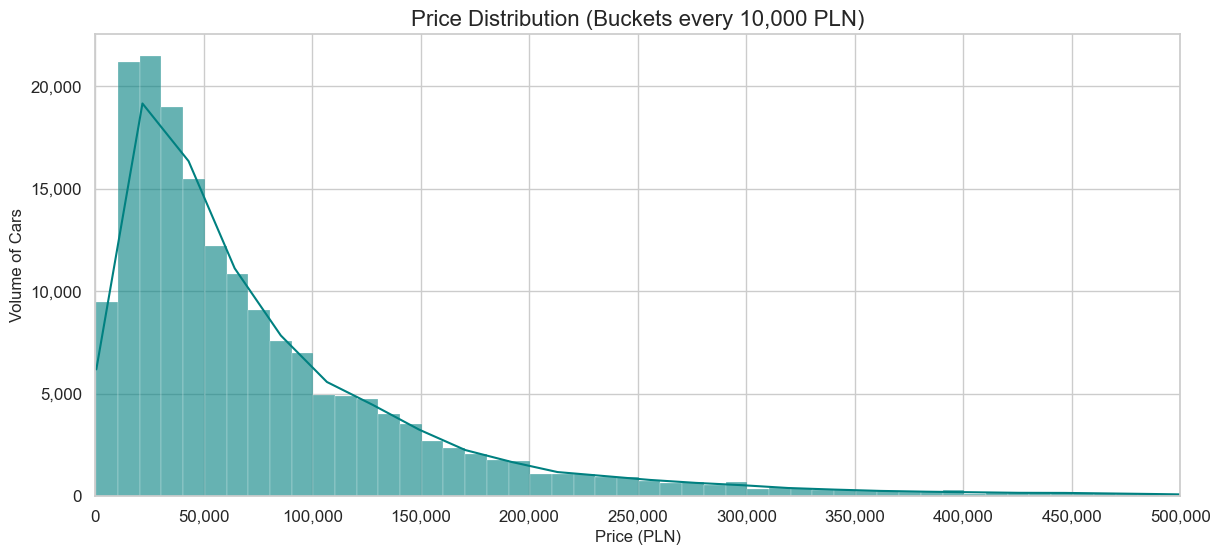

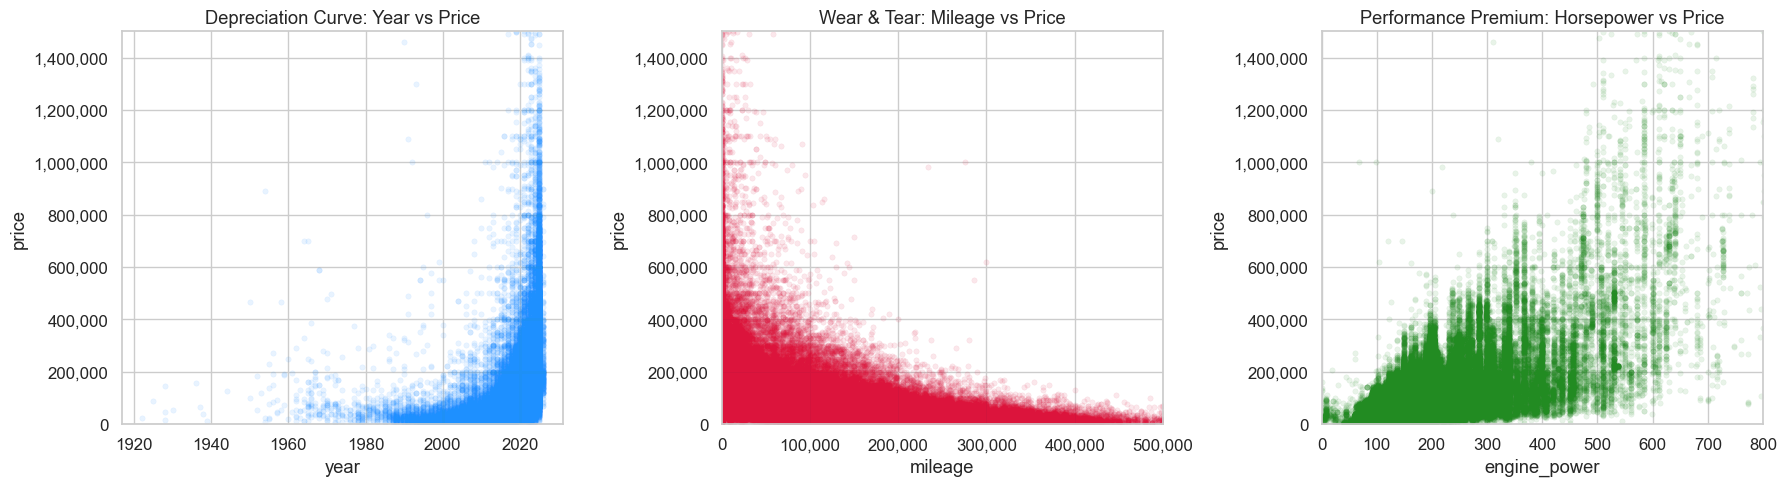

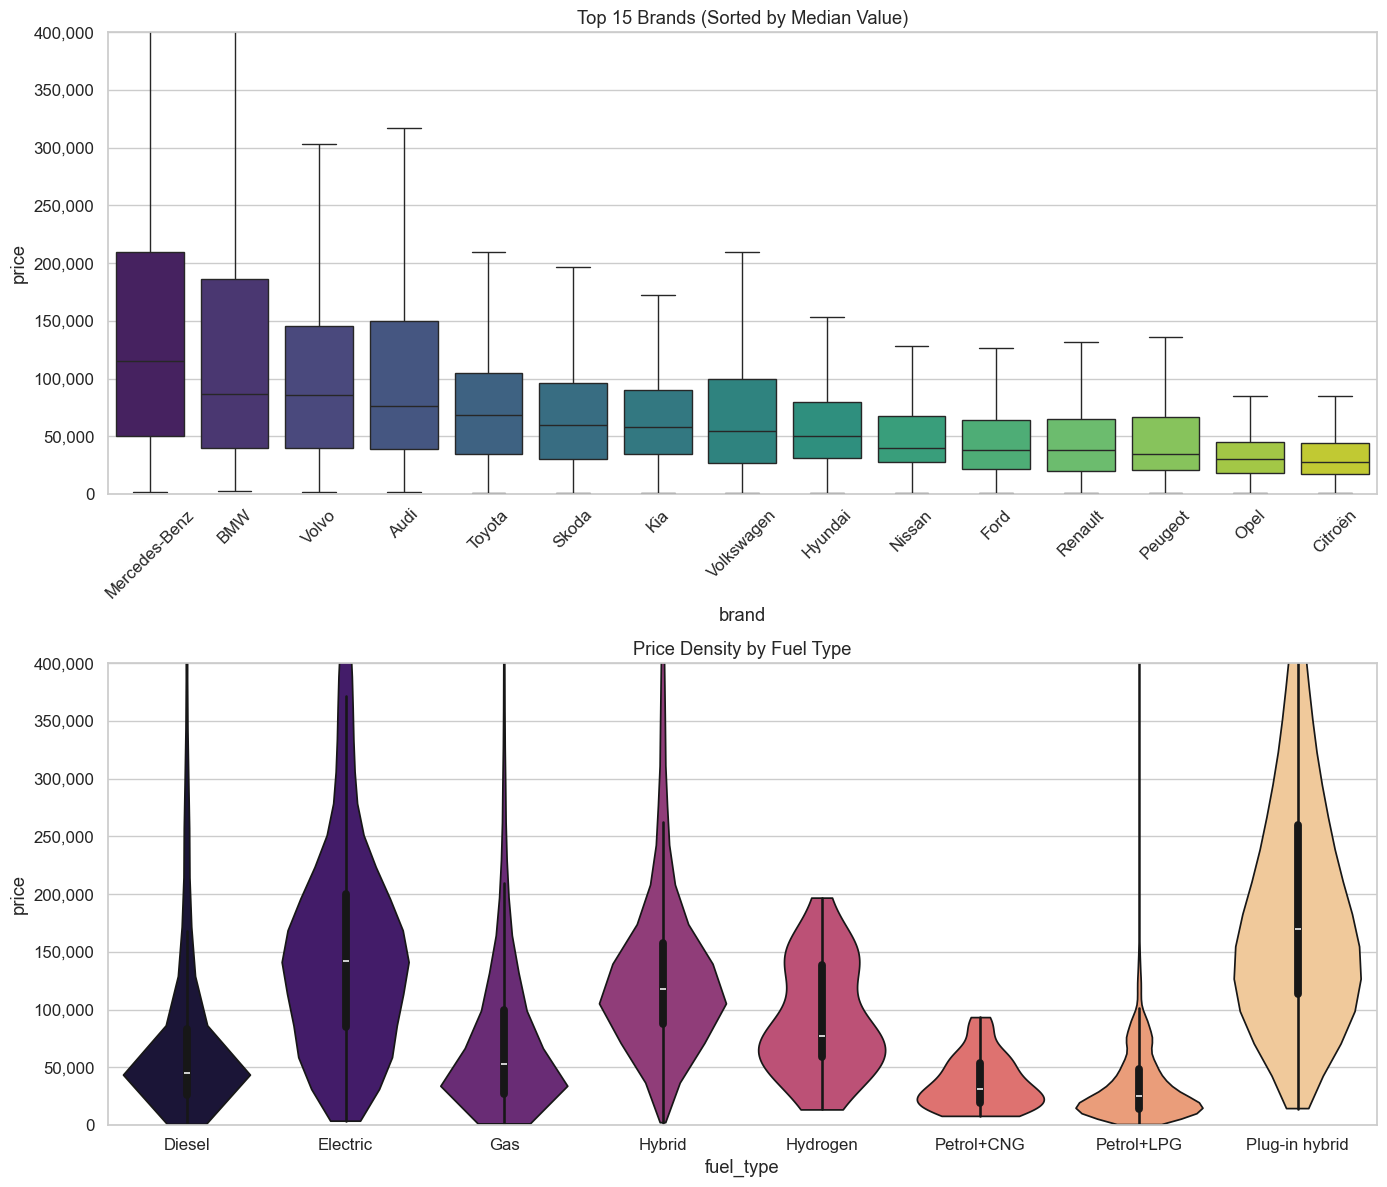

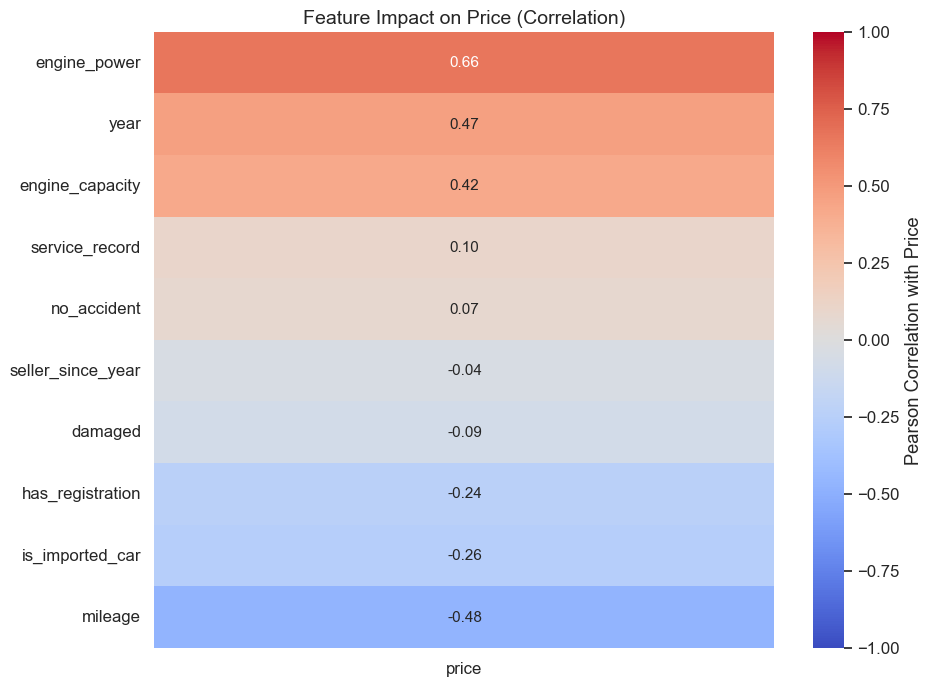

In [7]:
# ==========================================
# 1. DEPENDENCY CHECK
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd

if 'X_train_full' not in locals() or 'y_train_full' not in locals():
    raise SystemExit("⛔ Data not found! Please run Cell 3 first.")

print("📊 Visualizing Market Physics...")

# Reconstruct a temporary DataFrame for plotting (Features + Target)
df_eda = X_train_full.copy()
df_eda['price'] = y_train_full

# ==========================================
# 2. GLOBAL PLOTTING STYLE
# ==========================================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
price_fmt = ticker.StrMethodFormatter('{x:,.0f}')

# ==========================================
# 3. TARGET VARIABLE DISTRIBUTION
# ==========================================
plt.figure(figsize=(14, 6))
ax = sns.histplot(df_eda['price'], binwidth=10000, kde=True, color='teal', alpha=0.6)
plt.title("Price Distribution (Buckets every 10,000 PLN)", fontsize=16)
plt.xlabel("Price (PLN)", fontsize=12)
plt.ylabel("Volume of Cars", fontsize=12)
plt.xlim(0, 500000) 
ax.xaxis.set_major_locator(ticker.MultipleLocator(50000))
ax.xaxis.set_major_formatter(price_fmt)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=0)
plt.show()

# ==========================================
# 4. CONTINUOUS VARIABLES (The "Big Three")
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_kws = {'alpha': 0.1, 'edgecolor': None, 's': 15} 

# A. Year vs Price
sns.scatterplot(data=df_eda, x='year', y='price', ax=axes[0], color='dodgerblue', **scatter_kws)
axes[0].set_title("Depreciation Curve: Year vs Price")
axes[0].set_ylim(0, 1500000)
axes[0].yaxis.set_major_formatter(price_fmt)

# B. Mileage vs Price
sns.scatterplot(data=df_eda, x='mileage', y='price', ax=axes[1], color='crimson', **scatter_kws)
axes[1].set_title("Wear & Tear: Mileage vs Price")
axes[1].set_ylim(0, 1500000)
axes[1].set_xlim(0, 500000)
axes[1].yaxis.set_major_formatter(price_fmt)
axes[1].xaxis.set_major_formatter(price_fmt)

# C. Power vs Price
sns.scatterplot(data=df_eda, x='engine_power', y='price', ax=axes[2], color='forestgreen', **scatter_kws)
axes[2].set_title("Performance Premium: Horsepower vs Price")
axes[2].set_ylim(0, 1500000)
axes[2].set_xlim(0, 800)
axes[2].yaxis.set_major_formatter(price_fmt)

plt.tight_layout()
plt.show()

# ==========================================
# 5. CATEGORICAL ANALYSIS (Brand & Fuel)
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# A. Top 15 Brands
top_brands = df_eda['brand'].value_counts().nlargest(15).index
brand_subset = df_eda[df_eda['brand'].isin(top_brands)].copy()
if brand_subset['brand'].dtype.name == 'category':
    brand_subset['brand'] = brand_subset['brand'].cat.remove_unused_categories()
brand_order = brand_subset.groupby('brand')['price'].median().sort_values(ascending=False).index

sns.boxplot(
    data=brand_subset, x='brand', y='price', 
    order=brand_order, ax=axes[0], palette="viridis", showfliers=False 
)
axes[0].set_title("Top 15 Brands (Sorted by Median Value)")
axes[0].set_ylim(0, 400000)
axes[0].yaxis.set_major_formatter(price_fmt)
axes[0].tick_params(axis='x', rotation=45)

# B. Fuel Type
sns.violinplot(data=df_eda, x='fuel_type', y='price', ax=axes[1], palette="magma", cut=0)
axes[1].set_title("Price Density by Fuel Type")
axes[1].set_ylim(0, 400000)
axes[1].yaxis.set_major_formatter(price_fmt)

plt.tight_layout()
plt.show()

# ==========================================
# 6. CORRELATION MATRIX (Updated)
# ==========================================
# Adjust height based on how many numeric columns we have
num_cols_count = len(df_eda.select_dtypes(include=[np.number]).columns)
plt.figure(figsize=(10, max(8, num_cols_count * 0.4))) # Dynamic height

# Select only numeric columns
numeric_df = df_eda.select_dtypes(include=[np.number])

# Calculate Correlation
correlation = numeric_df.corr()

# Filter: Sort by 'price' correlation, but DROP 'price' itself (row)
# We show ALL other features
heatmap_data = correlation[['price']].sort_values(by='price', ascending=False).drop('price')

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f",     # 2 decimal places
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    cbar_kws={'label': 'Pearson Correlation with Price'}
)
plt.title("Feature Impact on Price (Correlation)", fontsize=14)
plt.yticks(rotation=0) # Keep y-labels horizontal for readability
plt.show()

# Clean up memory
del df_eda

4. This module performs a competitive benchmark of 5 leading Machine Learning algorithms.
Goal: Identify which model provides the lowest Error (MAE) within a reasonable training time.


In [8]:
# --- 4. The Model Shootout: 5-Way Battle ---
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
from interpret.glassbox import ExplainableBoostingRegressor
from autogluon.tabular import TabularPredictor
import time
import pandas as pd
import warnings

# Suppress warnings to keep the output clean
warnings.filterwarnings('ignore')

# Initialize a list to store the metrics
results = []

print("🏁 Starting Model Benchmark...")

# ==========================================
# 1. XGBoost (eXtreme Gradient Boosting)
# ==========================================
print("\n🚀 Training XGBoost...")
start = time.time()

# We use 'hist' tree method for faster training on large data
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6,
    tree_method="hist", 
    device=config.DEVICE, 
    enable_categorical=True,
    n_jobs=-1
)

xgb_model.fit(X_train_full, y_train_full)
xgb_preds = xgb_model.predict(X_holdout)

results.append({
    "Model": "XGBoost", 
    "MAE": mean_absolute_error(y_holdout, xgb_preds),
    "R2": r2_score(y_holdout, xgb_preds),
    "Time (s)": round(time.time() - start, 2)
})

# ==========================================
# 2. LightGBM (Light Gradient Boosting)
# ==========================================
print("🚀 Training LightGBM...")
start = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=config.RANDOM_SEED,
    verbose=-1,
    n_jobs=-1
)

lgb_model.fit(X_train_full, y_train_full)
lgb_preds = lgb_model.predict(X_holdout)

results.append({
    "Model": "LightGBM", 
    "MAE": mean_absolute_error(y_holdout, lgb_preds),
    "R2": r2_score(y_holdout, lgb_preds),
    "Time (s)": round(time.time() - start, 2)
})

# ==========================================
# 3. CatBoost (Categorical Boosting)
# ==========================================
print("🚀 Training CatBoost...")
start = time.time()

# --- Pre-processing for CatBoost ---
# CatBoost crashes on NaNs in categorical columns, so we fill them with "Missing".

# A. Create independent copies
X_cb_train = X_train_full.copy()
X_cb_holdout = X_holdout.copy()

# B. Identify Categorical Columns
cat_cols = [c for c in X_cb_train.columns if X_cb_train[c].dtype.name == 'category']

# C. Fill NaNs safely
for c in cat_cols:
    if 'Missing' not in X_cb_train[c].cat.categories:
        X_cb_train[c] = X_cb_train[c].cat.add_categories('Missing')
    if 'Missing' not in X_cb_holdout[c].cat.categories:
        X_cb_holdout[c] = X_cb_holdout[c].cat.add_categories('Missing')
        
    X_cb_train[c] = X_cb_train[c].fillna('Missing')
    X_cb_holdout[c] = X_cb_holdout[c].fillna('Missing')

# D. Train
cb_model = cb.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE',
    random_seed=config.RANDOM_SEED,
    verbose=0,
    allow_writing_files=False
)

cb_model.fit(X_cb_train, y_train_full, cat_features=cat_cols)
cb_preds = cb_model.predict(X_cb_holdout)

results.append({
    "Model": "CatBoost", 
    "MAE": mean_absolute_error(y_holdout, cb_preds),
    "R2": r2_score(y_holdout, cb_preds),
    "Time (s)": round(time.time() - start, 2)
})

# ==========================================
# 4. EBM (Explainable Boosting Machine)
# ==========================================
print("🚀 Training EBM (Glassbox)...")
start = time.time()

# Optimization: Sample down to 50k rows if dataset is too large
if len(X_train_full) > 50000:
    print(f"   ⚡ Optimization: Sampling 50,000 rows for speed...")
    X_ebm = X_train_full.sample(50000, random_state=config.RANDOM_SEED)
    y_ebm = y_train_full.loc[X_ebm.index]
else:
    X_ebm, y_ebm = X_train_full, y_train_full

ebm = ExplainableBoostingRegressor(
    random_state=config.RANDOM_SEED, 
    n_jobs=-1, 
    outer_bags=4, 
    interactions=10
)
ebm.fit(X_ebm, y_ebm)
ebm_preds = ebm.predict(X_holdout)

results.append({
    "Model": "EBM (Sampled)", 
    "MAE": mean_absolute_error(y_holdout, ebm_preds),
    "R2": r2_score(y_holdout, ebm_preds),
    "Time (s)": round(time.time() - start, 2)
})

# ==========================================
# 5. AutoGluon (AutoML Ensembler)
# ==========================================
print("🚀 Training AutoGluon...")
start = time.time()

ag_train = X_train_full.copy()
ag_train[config.TARGET] = y_train_full

# time_limit=300 (5 mins) is a good balance for prototyping
ag_predictor = TabularPredictor(label=config.TARGET, verbosity=0, path='ag_models_benchmark').fit(
    ag_train, 
    time_limit=300, 
    presets='medium_quality'
)
ag_preds = ag_predictor.predict(X_holdout)

results.append({
    "Model": "AutoGluon", 
    "MAE": mean_absolute_error(y_holdout, ag_preds),
    "R2": r2_score(y_holdout, ag_preds),
    "Time (s)": round(time.time() - start, 2)
})

# ==========================================
# 6. Final Leaderboard
# ==========================================
print("\n" + "="*40)
print("🏆 FINAL RESULTS (Sorted by Lowest Error)")
print("="*40)

leaderboard = pd.DataFrame(results).sort_values(by="MAE")

display(leaderboard.style.background_gradient(cmap='Greens_r', subset=['MAE']))

print("\n💡 NOTE: The 'Winner' should be selected based on a balance of MAE (Accuracy) and Time (Efficiency).")

🏁 Starting Model Benchmark...

🚀 Training XGBoost...
🚀 Training LightGBM...
🚀 Training CatBoost...
🚀 Training EBM (Glassbox)...
   ⚡ Optimization: Sampling 50,000 rows for speed...
🚀 Training AutoGluon...

🏆 FINAL RESULTS (Sorted by Lowest Error)


,Model,MAE,R2,Time (s)
4,AutoGluon,9197.411185,0.952781,320.840000
1,LightGBM,9678.406854,0.949987,22.110000
0,XGBoost,10568.444085,0.930433,34.910000
2,CatBoost,11482.783309,0.895396,276.490000
3,EBM (Sampled),17864.358628,0.866845,26.070000



💡 NOTE: The 'Winner' should be selected based on a balance of MAE (Accuracy) and Time (Efficiency).


4.5 This module trains the "Heavyweight" AutoGluon model using Stacking and Bagging.

CRITICAL CONFIGURATION FOR WINDOWS USERS:
We set `dynamic_stacking=False`.
Why? AutoGluon's dynamic stacking attempts to delete temporary models while they 
are still in memory during validation. On Linux, this is fine. On Windows, 
this causes a `PermissionError` and crashes the pipeline. Disabling it makes 
training slightly slower but stable on Windows.

In [9]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error
import time
import pandas as pd
import numpy as np
import sys

# ==========================================
# 1. DEPENDENCY CHECK
# ==========================================
if 'X_train_full' not in locals():
    sys.exit("⛔ Data not found! Please run Preprocessing/Benchmark cells first.")

print("🚀 Starting AutoGluon 'Best Quality' Training...")
print("   ℹ️  Strategy: Multi-layer Stacking & Bagging (Ensemble of Ensembles).")

start = time.time()

# ==========================================
# 2. DATA SETUP
# ==========================================
# AutoGluon requires the target column to be present in the dataframe
ag_train = X_train_full.copy()
ag_train[config.TARGET] = y_train_full

# ==========================================
# 3. TRAINING ENGINE
# ==========================================
# 'best_quality' enables multi-layer stacking, which is significantly more accurate but slower.
ag_predictor_pro = TabularPredictor(
    label=config.TARGET,
    eval_metric='mean_absolute_error',
    path="ag_models_pro", 
    verbosity=2
).fit(
    ag_train, 
    time_limit=1800,           # 30-minute soft time limit
    presets='best_quality',    # Enables advanced stacking and bagging
    auto_stack=True,           # Ensures stacking is used even for smaller datasets
    dynamic_stacking=False     # Windows Fix: Prevents PermissionError during training
)

# ==========================================
# 4. EVALUATION & ROI ANALYSIS
# ==========================================
print("\n📊 Evaluating 'Pro' Model Performance...")

# Generate predictions on the Holdout set
pro_preds = ag_predictor_pro.predict(X_holdout)

# --- A. Calculate ALL Critical Metrics ---
mae_pro = mean_absolute_error(y_holdout, pro_preds)
r2_pro = r2_score(y_holdout, pro_preds)
median_ae_pro = median_absolute_error(y_holdout, pro_preds)
max_error_pro = np.max(np.abs(y_holdout - pro_preds))

# MAPE (Mean Absolute Percentage Error) - Handling division by zero safety
mask = y_holdout != 0
mape_pro = np.mean(np.abs((y_holdout[mask] - pro_preds[mask]) / y_holdout[mask])) * 100

time_taken = time.time() - start

# --- B. Display Professional Report ---
print("-" * 50)
print(f"🌟 NEW MODEL SCORECARD")
print("-" * 50)
print(f"   🔹 MAE (Mean Error):   {mae_pro:,.0f} PLN")
print(f"   🔹 MAPE (Perc Error):  {mape_pro:.2f}%")
print(f"   🔹 Median Error:       {median_ae_pro:,.0f} PLN")
print(f"   🔹 Max Error:          {max_error_pro:,.0f} PLN")
print(f"   🔹 R² Score:           {r2_pro:.4f}")
print("-" * 50)

# --- C. Compare with Baseline ---
# We retrieve the best MAE from the leaderboard generated in the previous shootout script.
if 'leaderboard' in locals() and not leaderboard.empty:
    # Find the minimum MAE in the existing results
    baseline_mae = leaderboard['MAE'].min()
    # Identify which model achieved that best score
    baseline_name = leaderboard.loc[leaderboard['MAE'].idxmin(), 'Model']
    print(f"✅ Baseline set from Leaderboard: {baseline_mae:,.0f} PLN ({baseline_name})")
else:
    # Fallback if no leaderboard is found in memory
    baseline_mae = 10361 
    baseline_name = "Default Benchmark"
    print(f"⚠️ Leaderboard not found. Using default placeholder baseline.")

# Calculate net improvement
improvement_pln = baseline_mae - mae_pro
improvement_pct = (improvement_pln / baseline_mae) * 100

print("-" * 50)
print(f"⏱️  Total Training Time: {time_taken/60:.1f} minutes")
print("-" * 50)
print(f"📉 Baseline MAE ({baseline_name}): {baseline_mae:,.0f} PLN")
print(f"📉 New 'Pro' MAE:               {mae_pro:,.0f} PLN")
print(f"🚀 Net Improvement:            {improvement_pln:+,.0f} PLN ({improvement_pct:+.2f}%)")
print("-" * 50)

# ==========================================
# 5. DECISION LOGIC
# ==========================================
if mae_pro < baseline_mae:
    print(f"✅ SUCCESS: The 'Best Quality' ensemble outperformed {baseline_name}!")
    # Update the global predictor variable to use the new champion
    ag_predictor = ag_predictor_pro 
    
    # Save a flag to indicate the successful upgrade
    with open("model_version.txt", "w") as f:
        f.write(f"Pro Model (MAE: {mae_pro:.0f})")
else:
    print(f"⚠️ DIMINISHING RETURNS: This ensemble is not better than {baseline_name}.")
    print("   Recommendation: Stick with your current best-performing model.")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.4
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       14.93 GB / 31.73 GB (47.0%)
Disk Space Avail:   280.77 GB / 930.40 GB (30.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1


🚀 Starting AutoGluon 'Best Quality' Training...
   ℹ️  Strategy: Multi-layer Stacking & Bagging (Ensemble of Ensembles).


Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "c:\Users\pawel\Documents\Python_projects\otomoto\ML_car_valuation_otomoto\ag_models_pro"
Train Data Rows:    180823
Train Data Columns: 24
Label Column:       price
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (4230000.0, 500.0, 86841.123, 113328.47145)
	If 'regression' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    15264.50 MB
	Train Data (Original)  Memory Usage: 19.50 MB (0.1% of available memory)
	Inferring data type of each feature based o


📊 Evaluating 'Pro' Model Performance...
--------------------------------------------------
🌟 NEW MODEL SCORECARD
--------------------------------------------------
   🔹 MAE (Mean Error):   8,548 PLN
   🔹 MAPE (Perc Error):  13.69%
   🔹 Median Error:       3,870 PLN
   🔹 Max Error:          1,273,053 PLN
   🔹 R² Score:           0.9551
--------------------------------------------------
✅ Baseline set from Leaderboard: 9,197 PLN (AutoGluon)
--------------------------------------------------
⏱️  Total Training Time: 32.1 minutes
--------------------------------------------------
📉 Baseline MAE (AutoGluon): 9,197 PLN
📉 New 'Pro' MAE:               8,548 PLN
🚀 Net Improvement:            +649 PLN (+7.06%)
--------------------------------------------------
✅ SUCCESS: The 'Best Quality' ensemble outperformed AutoGluon!


4.6 Compare the models

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PREDICTION AGGREGATION
# ==========================================
print("🔄 Gathering predictions from all active models...")

all_preds = {}

# AutoGluon
if 'ag_predictor' in locals():
    all_preds['AutoGluon'] = ag_predictor.predict(X_holdout)

# XGBoost
if 'xgb_model' in locals():
    all_preds['XGBoost'] = xgb_model.predict(X_holdout)

# CatBoost (requires specific handling for categorical missing values)
if 'cb_model' in locals():
    # Use X_cb_holdout if it exists from previous shootout script
    all_preds['CatBoost'] = cb_model.predict(X_cb_holdout if 'X_cb_holdout' in locals() else X_holdout)

# LightGBM
if 'lgb_model' in locals():
    all_preds['LightGBM'] = lgb_model.predict(X_holdout)

# EBM
if 'ebm' in locals():
    all_preds['EBM'] = ebm.predict(X_holdout)

# ==========================================
# 2. DEFINE PRICE SEGMENTS
# ==========================================
# Define tiers based on Polish market reality
bins = [0, 30000, 70000, 150000, 300000, 10000000]
labels = ['Budget (<30k)', 'Economy (30k-70k)', 'Mid-Range (70k-150k)', 'Premium (150k-300k)', 'Luxury (>300k)']

# ==========================================
# 3. CORE EVALUATION ENGINE
# ==========================================
matrix_data = []

for model_name, preds in all_preds.items():
    # Create temp dataframe for this model's results
    temp_df = pd.DataFrame({
        'actual': y_holdout,
        'pred': preds
    })
    temp_df['segment'] = pd.cut(temp_df['actual'], bins=bins, labels=labels)
    
    # Calculate global metrics
    for segment in labels:
        subset = temp_df[temp_df['segment'] == segment]
        if len(subset) == 0: continue
        
        y_true = subset['actual']
        y_pred = subset['pred']
        
        # Calculations
        mae = mean_absolute_error(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else 0
        max_err = np.max(np.abs(y_true - y_pred))
        med_ae = median_absolute_error(y_true, y_pred)
        
        matrix_data.append({
            'Model': model_name,
            'Segment': segment,
            'MAE (PLN)': mae,
            'MAPE (%)': mape,
            'R2 Score': r2,
            'Max Error (PLN)': max_err,
            'Median AE (PLN)': med_ae,
            'Samples': len(subset)
        })

# ==========================================
# 4. DATA PRESENTATION (MATRIX)
# ==========================================
full_matrix = pd.DataFrame(matrix_data)

# Pivot the data to create a high-level comparison matrix for MAE
mae_matrix = full_matrix.pivot(index='Model', columns='Segment', values='MAE (PLN)')

print("\n🏆 SEGMENTED MAE MATRIX (PLN Error - Lower is Better)")
display(mae_matrix.style.background_gradient(cmap='RdYlGn_r', axis=0).format("{:,.0f}"))

print("\n📊 DETAILED PERFORMANCE SCORECARD")
# Sort by Model and Segment for the full table
display(full_matrix.sort_values(['Segment', 'MAE (PLN)']).style.format({
    'MAE (PLN)': '{:,.0f}',
    'MAPE (%)': '{:.2f}%',
    'R2 Score': '{:.3f}',
    'Max Error (PLN)': '{:,.0f}',
    'Median AE (PLN)': '{:,.0f}'
}).background_gradient(cmap='RdYlGn_r', subset=['MAE (PLN)', 'MAPE (%)']))

🔄 Gathering predictions from all active models...

🏆 SEGMENTED MAE MATRIX (PLN Error - Lower is Better)


Segment,Budget (<30k),Economy (30k-70k),Luxury (>300k),Mid-Range (70k-150k),Premium (150k-300k)
Model,,,,,
AutoGluon,"3,267","5,123","54,494","8,627","16,920"
CatBoost,"3,393","5,600","91,701","10,908","24,448"
EBM,"10,223","12,626","96,868","17,103","28,536"
LightGBM,"3,876","5,894","59,206","9,866","19,028"
XGBoost,"4,122","6,006","73,857","10,091","20,792"



📊 DETAILED PERFORMANCE SCORECARD


,Model,Segment,MAE (PLN),MAPE (%),R2 Score,Max Error (PLN),Median AE (PLN),Samples
0,AutoGluon,Budget (<30k),"3,267",24.21%,0.360,"209,417","2,154",12932
10,CatBoost,Budget (<30k),"3,393",24.55%,0.462,"170,115","2,365",12932
15,LightGBM,Budget (<30k),"3,876",28.76%,0.158,"229,181","2,671",12932
5,XGBoost,Budget (<30k),"4,122",30.00%,-0.078,"343,641","2,795",12932
20,EBM,Budget (<30k),"10,223",80.03%,-3.941,"346,862","7,417",12932
1,AutoGluon,Economy (30k-70k),"5,123",10.79%,0.387,"379,909","3,400",14281
11,CatBoost,Economy (30k-70k),"5,600",11.66%,0.368,"222,345","3,815",14281
16,LightGBM,Economy (30k-70k),"5,894",12.42%,0.269,"230,093","4,036",14281
6,XGBoost,Economy (30k-70k),"6,006",12.67%,0.156,"319,021","4,117",14281
21,EBM,Economy (30k-70k),"12,626",26.80%,-2.238,"471,549","8,987",14281


4.6 Save the models

In [11]:
# ==============================================================================
# PERMANENT STORAGE: EXPORTING THE CHAMPION MODEL (AUTOGLUON)
# ==============================================================================
import pickle
import os
import shutil
import stat
import gc

# Helper function to force delete Read-Only files on Windows
def remove_readonly(func, path, exc_info):
    # Clear the Read-Only bit and try again
    os.chmod(path, stat.S_IWRITE)
    func(path)

# 1. Prepare destination directory
os.makedirs('saved_models', exist_ok=True)

# 2. ARCHIVE AUTOGLUON PRO
ag_source_path = "ag_models_pro"
ag_dest_path = "saved_models/autogluon_pro_ensemble"

# Optional: Clear memory to ensure no files are locked by the notebook
if 'predictor' in locals():
    del predictor
    gc.collect()

if os.path.exists(ag_source_path):
    # If the destination folder already exists, remove it safely
    if os.path.exists(ag_dest_path):
        print(f"🔄 Cleaning up old backup at: {ag_dest_path}")
        # 'onerror' uses our helper to fix PermissionErrors automatically
        shutil.rmtree(ag_dest_path, onerror=remove_readonly)
    
    # Copy the entire model "brain" to the saved_models folder
    # We use copytree with dirs_exist_ok=True (Python 3.8+) just in case
    shutil.copytree(ag_source_path, ag_dest_path, dirs_exist_ok=True)
    print(f"✅ AutoGluon Pro Ensemble saved successfully to: {ag_dest_path}")
else:
    print(f"⚠️ ERROR: Source folder '{ag_source_path}' does not exist.")
    print("   Ensure that the Pro model training completed successfully.")

# 3. SAVE FEATURE LIST (CRITICAL)
if 'X_train_full' in locals():
    feature_list = X_train_full.columns.tolist()
    with open('saved_models/feature_columns.pkl', 'wb') as f:
        pickle.dump(feature_list, f)
    print("✅ Feature column list (feature_columns.pkl) has been secured.")
else:
    print("⚠️ WARNING: 'X_train_full' not found in memory. Feature list was not saved.")

print("-" * 50)
print("📂 Folder 'saved_models' is ready for production deployment!")

🔄 Cleaning up old backup at: saved_models/autogluon_pro_ensemble
✅ AutoGluon Pro Ensemble saved successfully to: saved_models/autogluon_pro_ensemble
✅ Feature column list (feature_columns.pkl) has been secured.
--------------------------------------------------
📂 Folder 'saved_models' is ready for production deployment!


5. This module visualizes the "Brain" of the Explainable Boosting Machine.
Unlike XGBoost (Blackbox), EBM is Additive:
    Price = Base + f(Year) + f(Mileage) + ...

We plot these 'f(x)' curves to see exactly how much PLN value is added or lost
at every specific year or mileage point.

🔍 Extracting Model Logic (Global Explanation)...
📊 Top 9 Drivers of Price:
   ['year', 'mileage', 'engine_power', 'model', 'generation', 'engine_capacity', 'brand', 'fuel_type', 'new_used']

📈 Plotting Impact Curves...


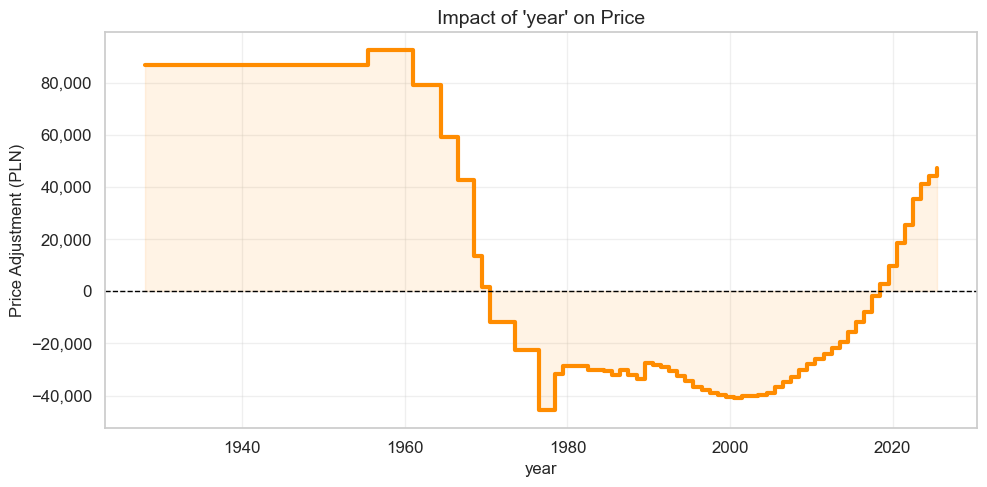

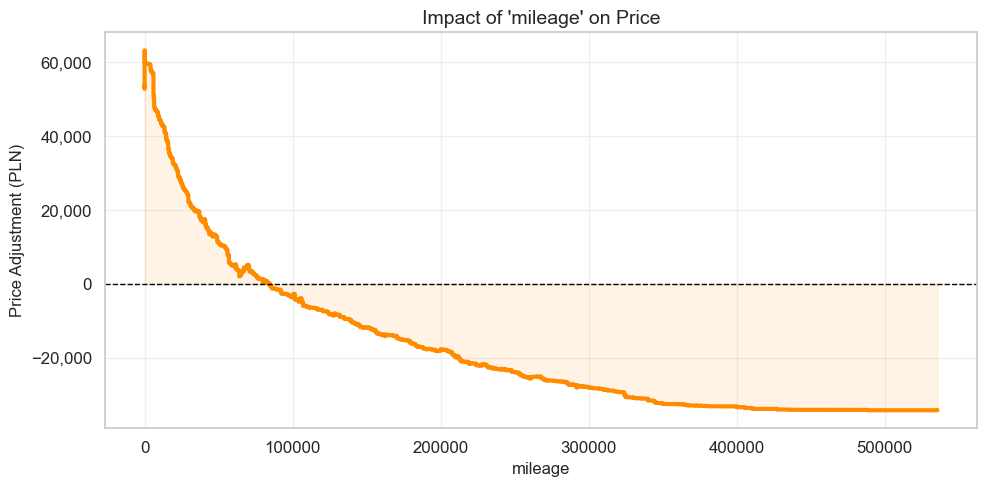

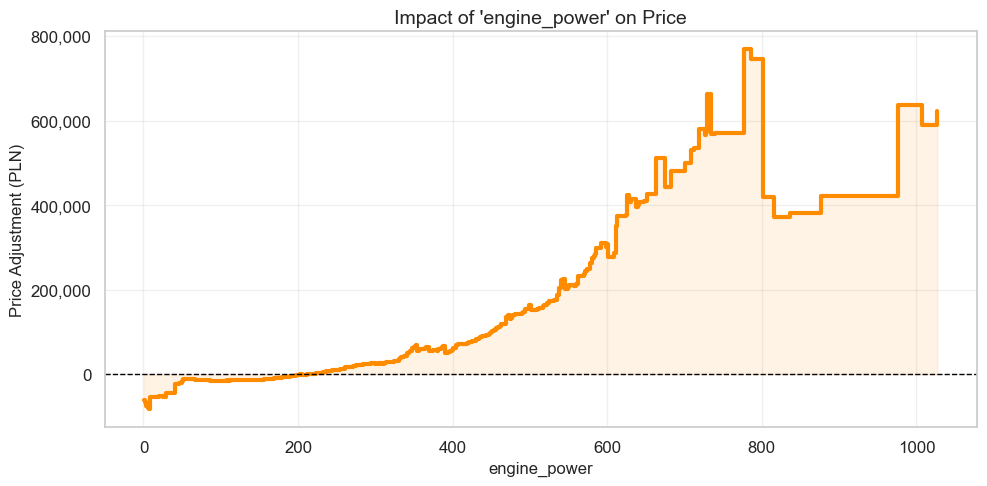

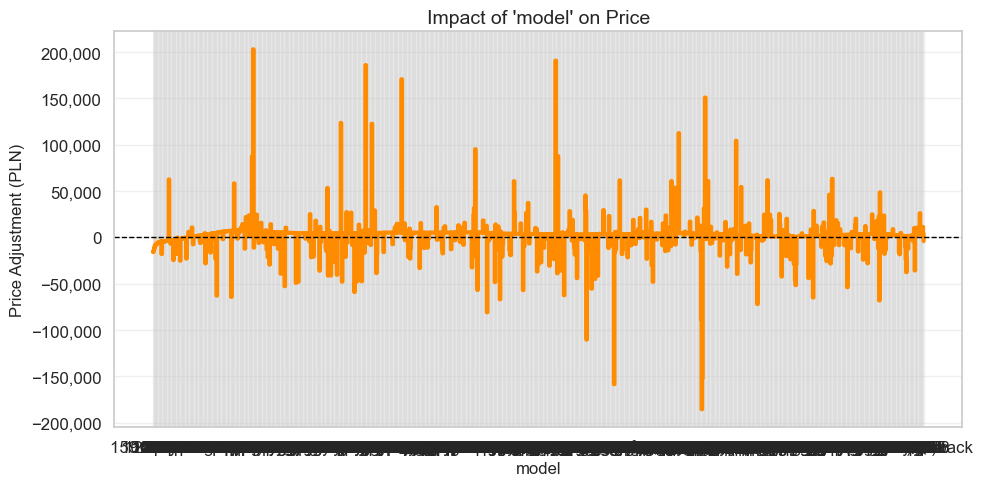

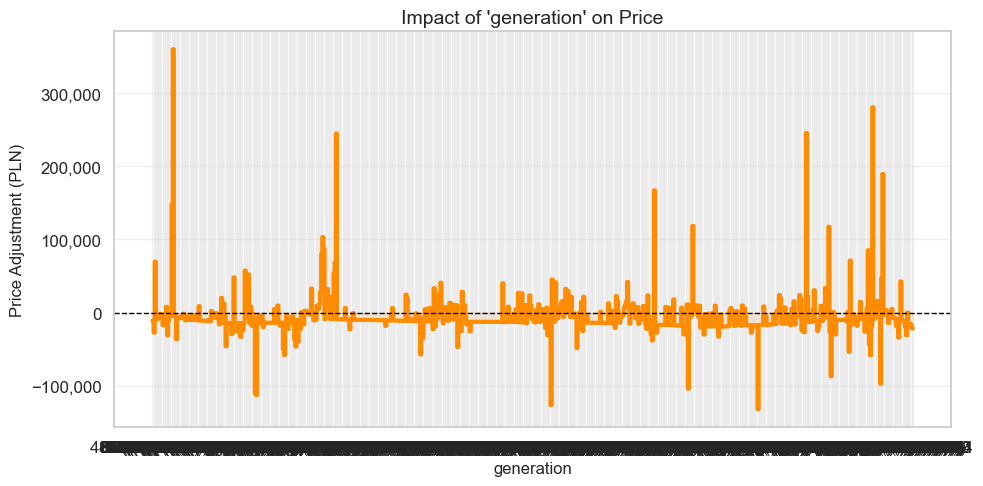

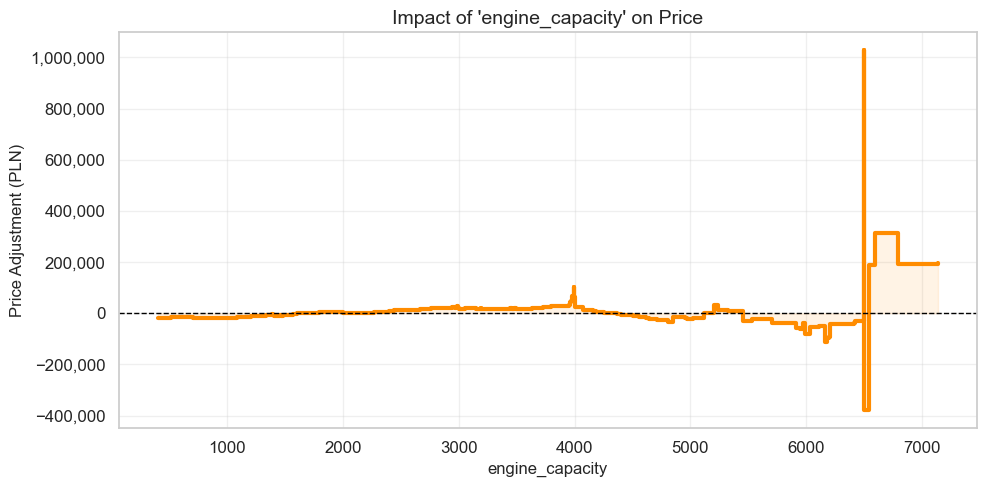

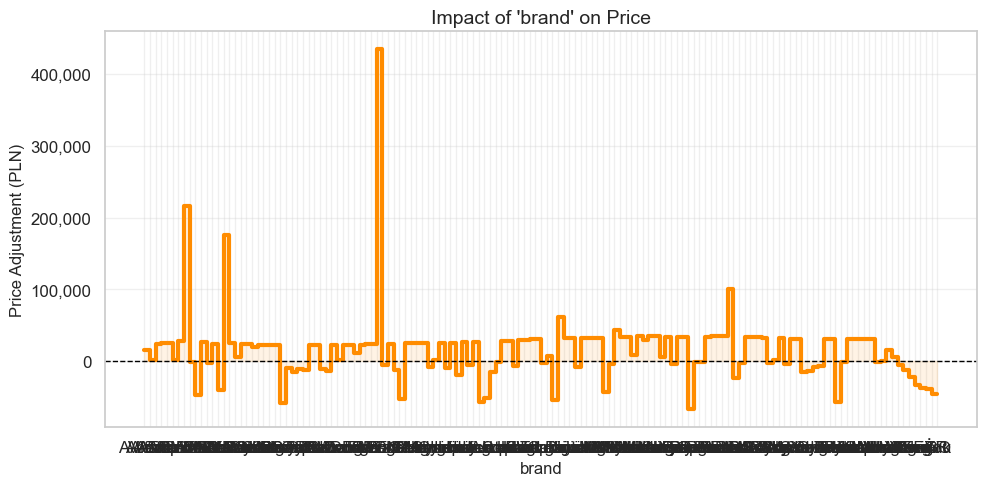

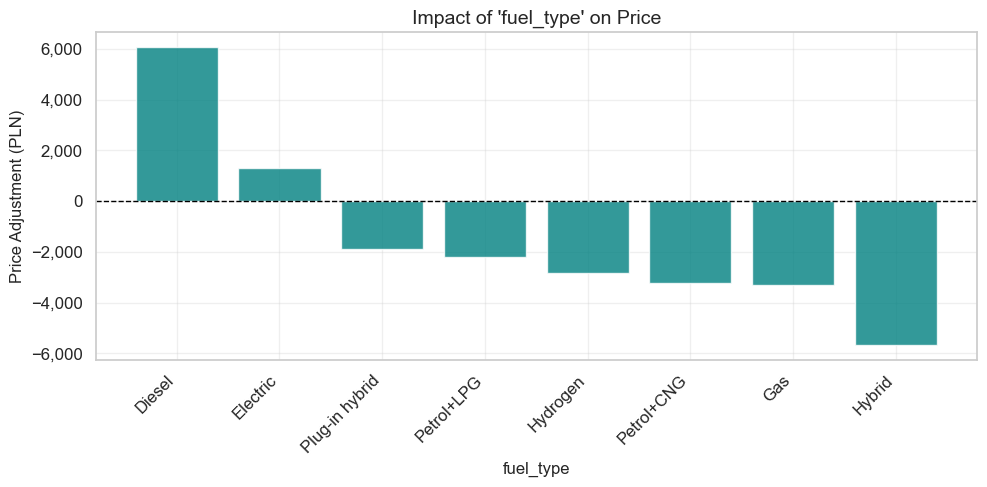

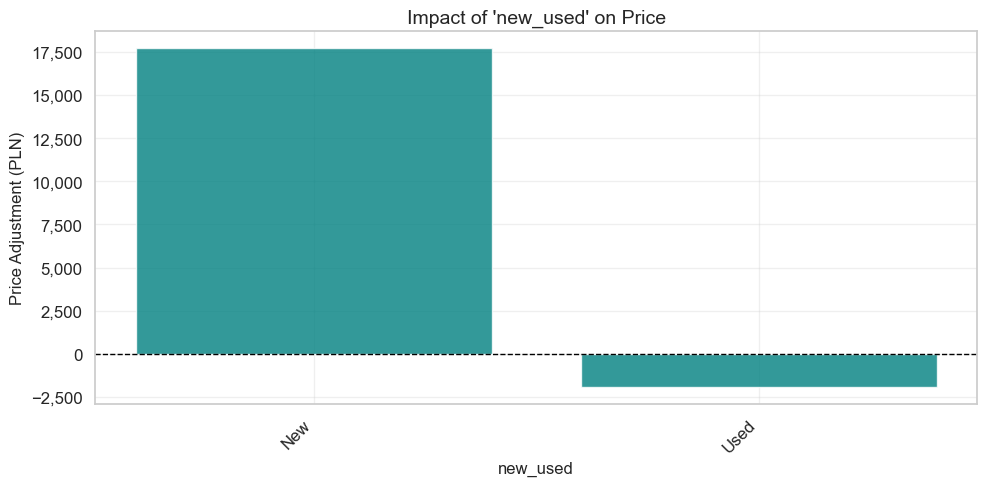

🖥️ Launching Interactive Dashboard (Check tabs)...


<!-- http://127.0.0.1:7001/1496251794208/ -->

In [12]:
# --- 5. EBM Insights  ---
from interpret import show
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import sys

# ==========================================
# 1. DEPENDENCY CHECK
# ==========================================
if 'ebm' not in locals():
    # Warn but don't crash if they skipped Cell 4
    print("⚠️ EBM model not found. Skipping interpretation.")
    print("   (Run Cell 4 to train the EBM model first.)")
else:
    print("🔍 Extracting Model Logic (Global Explanation)...")

    # ==========================================
    # 2. DATA EXTRACTION
    # ==========================================
    # The 'explain_global' method extracts the additive terms
    ebm_global = ebm.explain_global(name='EBM Car Pricing')

    summary_data = ebm_global.data()
    feature_names = summary_data['names']
    importances = summary_data['scores']

    # Sort features by absolute impact (High to Low)
    sorted_features = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
    
    # Select Top Features to Visualize (Don't plot everything)
    TOP_N = 9
    top_features = sorted_features[:TOP_N]

    print(f"📊 Top {len(top_features)} Drivers of Price:")
    print(f"   {[x[0] for x in top_features]}")

    # ==========================================
    # 3. CURVE VISUALIZATION LOOP
    # ==========================================
    print("\n📈 Plotting Impact Curves...")
    
    # Setup standard currency formatter
    price_fmt = ticker.StrMethodFormatter('{x:,.0f}')

    for feature_name, importance in top_features:
        try:
            # A. Extract Data for specific feature
            idx = feature_names.index(feature_name)
            data = ebm_global.data(idx)
            
            x_vals = data['names']   # The Bin Edges (e.g., Year 2010, 2011...)
            y_vals = data['scores']  # The Price Impact (e.g., +5000, -2000...)

            # B. CRITICAL FIX: Dimension Mismatch
            # For continuous vars, EBM returns N+1 "Edges" but only N "Scores".
            # Example: 10 Bins have 11 Edges (Start of Bin 1 ... End of Bin 10).
            # We must drop the last edge to match X and Y dimensions.
            if len(x_vals) == len(y_vals) + 1:
                x_vals = x_vals[:-1]
            
            # C. Plotting
            plt.figure(figsize=(10, 5))
            
            # Detect Categorical vs Continuous by checking first element type
            if len(x_vals) < 25 and isinstance(x_vals[0], str):
                # --- CATEGORICAL (Bar Chart) ---
                # Sort bars for cleaner look if not too many
                if len(x_vals) > 1:
                    # Zip, sort, unzip
                    sorted_pairs = sorted(zip(x_vals, y_vals), key=lambda x: x[1], reverse=True)
                    x_vals, y_vals = zip(*sorted_pairs)

                plt.bar(x_vals, y_vals, color='teal', alpha=0.8)
                plt.xticks(rotation=45, ha='right')
                
            else:
                # --- CONTINUOUS (Step Chart) ---
                # Step charts accurately represent the "Binning" nature of EBM
                plt.step(x_vals, y_vals, where='post', linewidth=3, color='darkorange')
                plt.fill_between(x_vals, y_vals, 0, color='darkorange', alpha=0.1, step='post')

            # D. Styling
            plt.axhline(0, color='black', linewidth=1, linestyle='--') # Zero line
            plt.title(f"Impact of '{feature_name}' on Price", fontsize=14)
            plt.ylabel("Price Adjustment (PLN)", fontsize=12)
            plt.xlabel(feature_name, fontsize=12)
            
            # Format Y-Axis with commas (1,000)
            plt.gca().yaxis.set_major_formatter(price_fmt)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"⚠️ Could not plot feature '{feature_name}': {e}")

    # ==========================================
    # 4. INTERACTIVE DASHBOARD
    # ==========================================
    # This launches a local web server (or widget in Notebook).
    # Wrapped in try/except because it can block execution in some environments.
    try:
        print("🖥️ Launching Interactive Dashboard (Check tabs)...")
        show(ebm_global)
    except Exception as e:
        print(f"ℹ️ Dashboard skipped: {e}")

5.5 This module asks the 'Winner' model (AutoGluon) what actually drives its decisions.

Method: Permutation Importance
------------------------------
AutoGluon uses a practical approach:
1. It takes the dataset and shuffles ONE column (e.g., 'Year').
2. It makes predictions with this shuffled (broken) data.
3. It measures how much the Error (MAE) INCREASES.
4. Higher Error Increase = More Important Feature.

Advantage: It works for ANY model (Ensembles, Neural Nets, etc.).

🕵️ Calculating Feature Importance via Permutation (Target: ~1-2 mins)...


Computing feature importance via permutation shuffling for 24 features using 2000 rows with 5 shuffle sets...
	1704.02s	= Expected runtime (340.8s per shuffle set)
	773.19s	= Actual runtime (Completed 5 of 5 shuffle sets)


📊 Top 3 Drivers: ['year', 'engine_power', 'mileage']


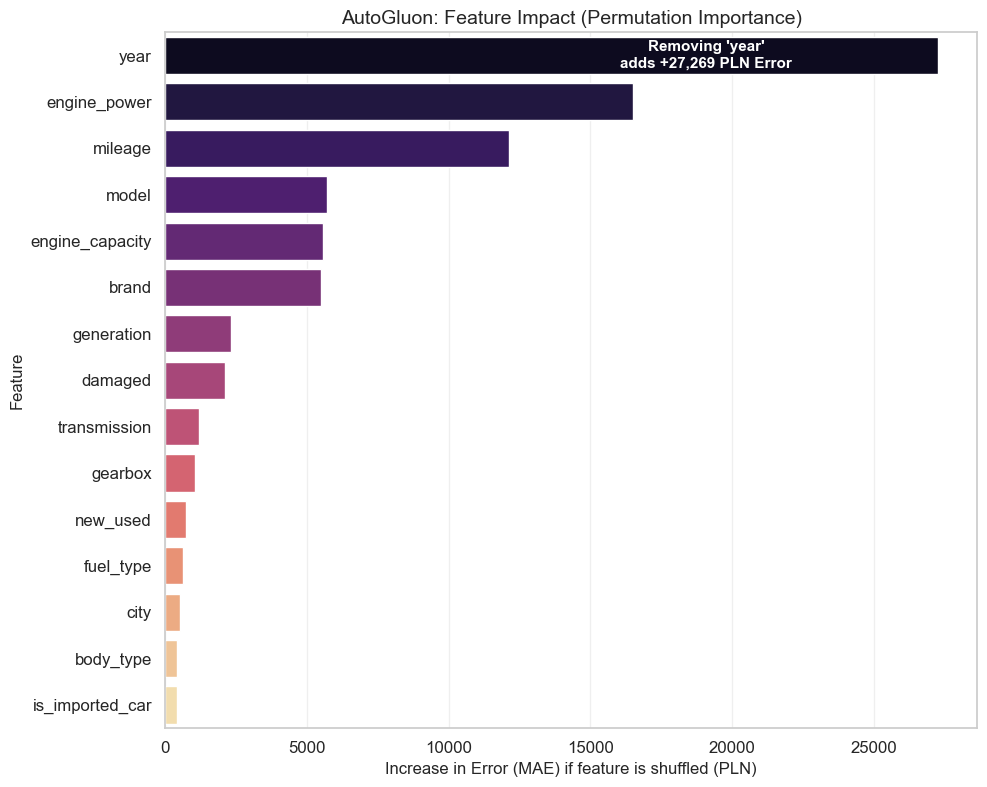

✅ Feature Audit Complete.


In [13]:


import matplotlib.pyplot as plt
import seaborn as sns
import sys

# ==========================================
# 1. DEPENDENCY CHECK
# ==========================================
if 'ag_predictor' not in locals():
    print("⚠️ AutoGluon model not found. Comparison skipped.")
else:
    print("🕵️ Calculating Feature Importance via Permutation (Target: ~1-2 mins)...")

    # ==========================================
    # 2. DATA PREPARATION (Fast Sampling)
    # ==========================================
    # Permutation is slow (it runs inference N times per feature).
    # We sample 2,000 rows to get a statistically significant result quickly.
    
    SAMPLE_SIZE = 2000
    if len(X_holdout) > SAMPLE_SIZE:
        X_ag_sample = X_holdout.sample(SAMPLE_SIZE, random_state=config.RANDOM_SEED)
        y_ag_sample = y_holdout.loc[X_ag_sample.index]
    else:
        X_ag_sample = X_holdout
        y_ag_sample = y_holdout

    # AutoGluon requires the target column inside the dataframe for this specific method
    ag_data = X_ag_sample.copy()
    ag_data[config.TARGET] = y_ag_sample

    # ==========================================
    # 3. CALCULATION
    # ==========================================
    # feature_importance returns a DataFrame with 'importance', 'stddev', 'p_value'
    ag_importance = ag_predictor.feature_importance(ag_data)

    # Filter for positive importance (Negative importance means feature was noise)
    ag_importance = ag_importance[ag_importance['importance'] > 0]
    
    # Select Top 15 for cleaner plotting
    top_features = ag_importance.head(15)

    print(f"📊 Top 3 Drivers: {top_features.index[:3].tolist()}")

    # ==========================================
    # 4. VISUALIZATION
    # ==========================================
    plt.figure(figsize=(10, 8))
    
    sns.barplot(
        x=top_features['importance'], 
        y=top_features.index, 
        palette='magma'
    )
    
    plt.title("AutoGluon: Feature Impact (Permutation Importance)", fontsize=14)
    plt.xlabel("Increase in Error (MAE) if feature is shuffled (PLN)", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    
    # Add annotation to the first bar to explain the metric
    max_imp = top_features['importance'].iloc[0]
    plt.text(
        max_imp * 0.7, 0, 
        f"Removing '{top_features.index[0]}'\nadds +{max_imp:,.0f} PLN Error", 
        color='white', va='center', ha='center', fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    print("✅ Feature Audit Complete.")

6. A dynamic benchmarking module that automatically detects trained models in the environment (AutoGluon, XGBoost, EBM, CatBoost, LightGBM) and performs a head-to-head comparison on the holdout dataset.

Key capabilities:
Dynamic Prediction Gathering: Automatically collects predictions from any model currently loaded in memory.
Business-Centric Metrics: Beyond standard R² and MAE, it calculates:
    - MAPE (Mean Absolute Percentage Error): The average error in percentage terms.
    * **Hit Rates (10% / 20%): The percentage of predictions that fell within 10% or 20% of the actual market price.
    * **Median Absolute Error: A robust metric that ignores outliers (e.g., damaged cars).
Visual Leaderboard: Generates a color-coded pandas dataframe sorting models by accuracy (Green = Good, Red = Bad).
Regression Plots: Creates side-by-side scatter plots (Actual vs. Predicted) with a "Perfect Fit" reference line to visually assess variance and bias across different price ranges.

📊 Running Comprehensive Model Showdown...
   🔹 Collecting AutoGluon predictions...
   🔹 Collecting XGBoost predictions...
   🔹 Collecting EBM predictions...

🏆 FINAL METRICS REPORT


,MAE (PLN),Median Err (PLN),MAPE (%),Hit Rate (10%),Hit Rate (20%),R2 Score
Model,,,,,,
AutoGluon,"8,548","3,870",13.69,60.5%,83.5%,0.9551
LightGBM,"9,678","4,576",15.98,54.6%,79.5%,0.9500
XGBoost,"10,568","4,716",16.63,52.6%,78.0%,0.9304
CatBoost,"11,483","4,545",15.23,52.5%,79.4%,0.8954
EBM,"17,864","10,196",37.80,30.5%,53.4%,0.8668


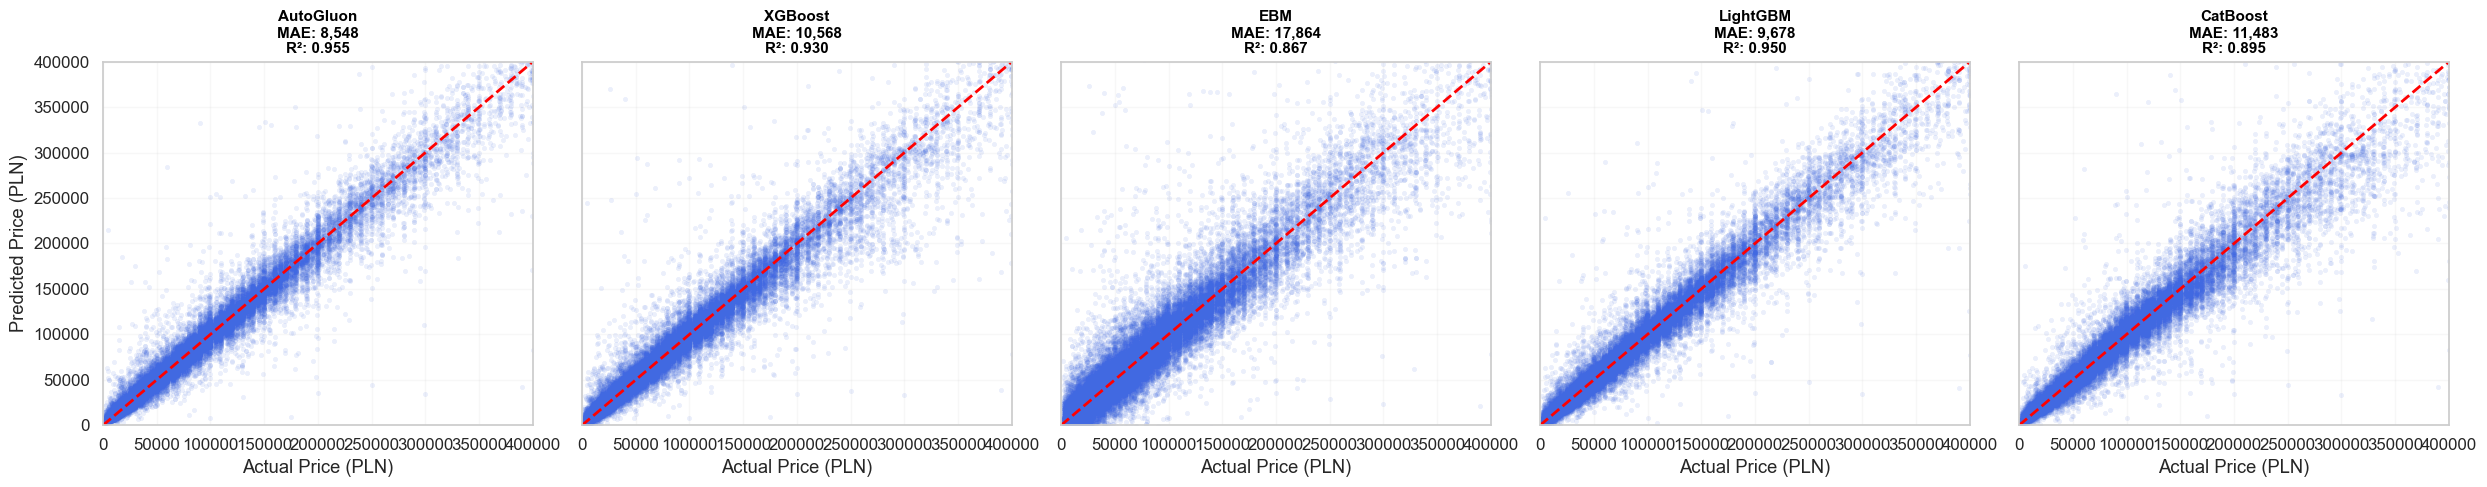

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, median_absolute_error, mean_absolute_error

print("📊 Running Comprehensive Model Showdown...")

# ==========================================
# 1. GATHER PREDICTIONS
# ==========================================
model_predictions = {}

# Check for AutoGluon
if 'ag_predictor' in locals():
    print("   🔹 Collecting AutoGluon predictions...")
    model_predictions['AutoGluon'] = ag_predictor.predict(X_holdout)

# Check for XGBoost
if 'xgb_model' in locals():
    print("   🔹 Collecting XGBoost predictions...")
    model_predictions['XGBoost'] = xgb_model.predict(X_holdout)

# Check for EBM
if 'ebm' in locals():
    print("   🔹 Collecting EBM predictions...")
    model_predictions['EBM'] = ebm.predict(X_holdout)

# Optional add-ins
if 'lgb_model' in locals():
    model_predictions['LightGBM'] = lgb_model.predict(X_holdout)
if 'cb_model' in locals():
    model_predictions['CatBoost'] = cb_model.predict(X_cb_holdout)

# ==========================================
# 2. CALCULATE BUSINESS METRICS
# ==========================================
results_audit = []

for name, preds in model_predictions.items():
    # Standard Technical Metrics
    mae = mean_absolute_error(y_holdout, preds)
    median_ae = median_absolute_error(y_holdout, preds)
    r2 = r2_score(y_holdout, preds)
    
    # Business Metrics (Percentage Errors)
    mask = y_holdout > 0
    y_true_safe = y_holdout[mask]
    preds_safe = preds[mask]
    
    # MAPE calculation
    mape = np.mean(np.abs((y_true_safe - preds_safe) / y_true_safe)) * 100
    
    # Error Vector for Hit Rate
    pct_error_vector = np.abs((y_true_safe - preds_safe) / y_true_safe) * 100
    hit_10 = (pct_error_vector < 10).mean() * 100 
    hit_20 = (pct_error_vector < 20).mean() * 100 
    
    results_audit.append({
        "Model": name,
        "MAE (PLN)": mae,
        "Median Err (PLN)": median_ae,
        "MAPE (%)": mape,
        "Hit Rate (10%)": hit_10,
        "Hit Rate (20%)": hit_20,
        "R2 Score": r2
    })

# ==========================================
# 3. DISPLAY LEADERBOARD
# ==========================================
audit_df = pd.DataFrame(results_audit).set_index("Model").sort_values(by="MAE (PLN)")

format_dict = {
    "MAE (PLN)": "{:,.0f}",
    "Median Err (PLN)": "{:,.0f}", 
    "MAPE (%)": "{:.2f}",
    "Hit Rate (10%)": "{:.1f}%",
    "Hit Rate (20%)": "{:.1f}%",
    "R2 Score": "{:.4f}"
}

print("\n🏆 FINAL METRICS REPORT")
display(audit_df.style.background_gradient(cmap='RdYlGn_r', subset=['MAE (PLN)', 'MAPE (%)', 'Median Err (PLN)'])
                  .background_gradient(cmap='RdYlGn', subset=['Hit Rate (10%)', 'Hit Rate (20%)', 'R2 Score'])
                  .format(format_dict))

# ==========================================
# 4. VISUALIZATION (Side-by-Side Scatter)
# ==========================================
num_models = len(model_predictions)

if num_models > 0:
    fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 5), sharey=True)
    if num_models == 1: axes = [axes]
    
    limit = 400000 
    
    for ax, (name, preds) in zip(axes, model_predictions.items()):
        # Actual vs Predicted
        sns.scatterplot(x=y_holdout, y=preds, alpha=0.1, ax=ax, s=10, color='royalblue', edgecolor=None)
        
        # Perfect Prediction Line
        ax.plot([0, limit], [0, limit], 'r--', lw=2, label='Perfect prediction')
        
        # Header Styling
        r2_val = r2_score(y_holdout, preds)
        mae_val = mean_absolute_error(y_holdout, preds)
        
        # Color coding title: Gold if it's the Blend
        title_color = 'darkorange' if name == 'Hybrid Blend' else 'black'
        ax.set_title(f"{name}\nMAE: {mae_val:,.0f}\nR²: {r2_val:.3f}", 
                     fontsize=11, fontweight='bold', color=title_color)
        
        ax.set_xlabel("Actual Price (PLN)")
        if ax == axes[0]: ax.set_ylabel("Predicted Price (PLN)")
        
        ax.set_xlim(0, limit)
        ax.set_ylim(0, limit)
        ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()

6.5 A deep-dive reliability suite designed to validate the model beyond simple accuracy metrics. It answers the question: "Is this model safe to deploy?"
Key Analyses Performed:
Residual Analysis: Visualizes Heteroscedasticity to check if the model becomes unstable at higher price points.
Market Segmentation: Breakdowns accuracy (MAPE & R²) by price tier (e.g., Budget vs. Luxury) to ensure fair performance across the board.
"The Black Book": Automatically extracts the Top 5 Worst Misses (Over/Under-priced) to help identify bad data or salvage titles.


🕵️ Starting Professional Model Audit (AutoGluon)...
   🤖 Auditing Model: AutoGluon


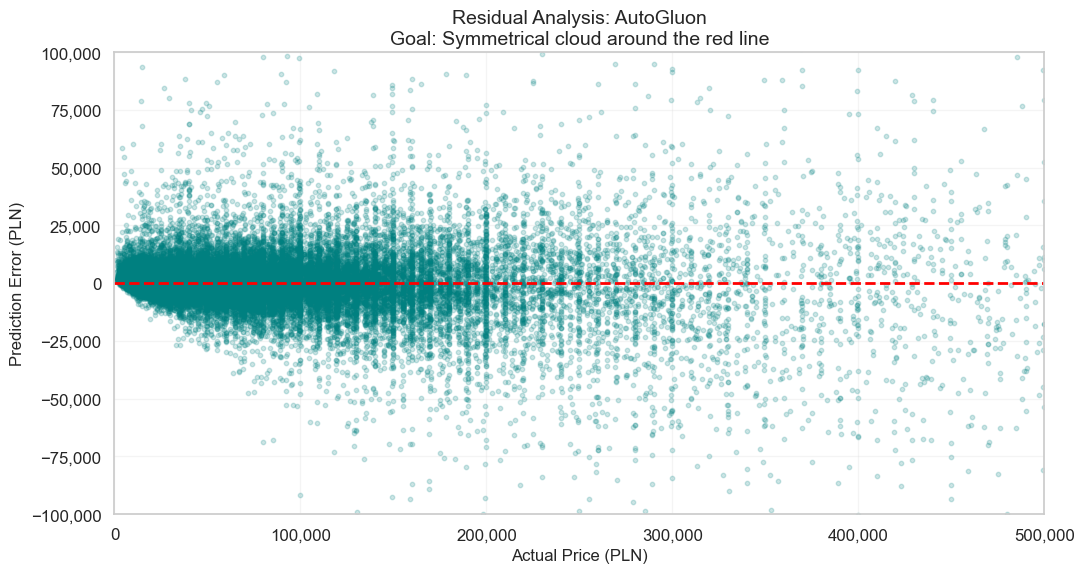


📊 SEGMENTATION PERFORMANCE (AutoGluon):


,Volume,Avg_Error_PLN,MAPE_Pct,R2_Score
Segment,,,,
Budget (<20k),"7,669","3,123",31.52%,-0.469
Economy (20k-50k),"13,744","4,199",12.34%,0.193
Mid-Range (50k-100k),"11,931","6,679",9.18%,0.418
Premium (100k-250k),"9,367","12,245",8.02%,0.748
Luxury (>250k),"2,405","37,970",8.98%,0.790



🚨 THE 'BLACK BOOK': Top 5 Worst Over-Valuations


,brand,model,year,mileage,Actual_Price,Predicted_Price,Error_PLN,Error_Pct
38465,Ferrari,FF,2015,24368.000000,"295,800","854,415","+558,615",+188.8%
13717,Mercedes-Benz,AMG GT,2022,15921.000000,"749,000","1,262,235","+513,235",+68.5%
11261,Mercedes-Benz,AMG GT,2023,10.000000,"783,627","1,282,258","+498,631",+63.6%
7729,Mercedes-Benz,AMG GT,2023,8000.000000,"770,000","1,196,731","+426,731",+55.4%
14333,Lamborghini,Urus,2023,16823.000000,"550,000","967,670","+417,670",+75.9%



🚨 THE 'BLACK BOOK': Top 5 Worst Under-Valuations


,brand,model,year,mileage,Actual_Price,Predicted_Price,Error_PLN,Error_Pct
21767,Subaru,Impreza,2010,140000.000000,"1,290,000","16,947","-1,273,053",-98.7%
4402,Volkswagen,Touran,2004,330000.000000,"1,000,000","8,507","-991,493",-99.1%
24276,Porsche,911,2025,14.000000,"2,190,000","1,227,660","-962,340",-43.9%
17966,Mercedes-Benz,ML,2008,231000.000000,"1,000,000","42,869","-957,131",-95.7%
20605,Mercedes-Benz,Klasa A,2021,59799.000000,"999,999","108,216","-891,783",-89.2%



📊 MODEL RELIABILITY ANALYSIS:
----------------------------------------
✅ Total predictions in Holdout set: 45,206
❌ Predictions with error > 100%:      537
📉 Percentage scale of problem:       1.19%
----------------------------------------

🧐 SAMPLE 'HALLUCINATIONS' (Top 5 biggest misses):


,brand,model,year,mileage,Actual_Price,Predicted_Price,Error_PLN,Error_Pct
14164,Ford,Tourneo Custom,2024,38666.000000,"5,009 PLN","214,426 PLN",209416.636250,+4180.6%
33321,BMW,3GT,2020,161000.000000,"3,900 PLN","62,532 PLN",58632.050781,+1503.4%
9888,Volvo,S90,2019,39000.000000,"4,900 PLN","59,683 PLN",54782.929688,+1118.0%
42967,BMW,Seria 3,2009,320000.000000,"1,000 PLN","10,996 PLN",9996.144531,+999.6%
36365,Audi,A6 Limousine,2004,280000.000000,"1,590 PLN","17,074 PLN",15484.458984,+973.9%



🔍 WHERE IS THE PROBLEM? (Errors >100% by segment):
Segment
Budget (<20k)           429
Economy (20k-50k)        78
Mid-Range (50k-100k)     21
Premium (100k-250k)       8
Luxury (>250k)            1
Name: count, dtype: int64

⚖️ BIAS SCORECARD: Where is the model consistently wrong?
(Positive % = Model Overprices | Negative % = Model Underprices)


,Volume,Avg Bias %
brand,,
Jaguar,162,+15.56%
Maserati,75,+13.83%
Infiniti,65,+10.29%
Alfa Romeo,287,+10.16%
Chevrolet,258,+9.62%
Chrysler,160,+8.13%
Suzuki,517,+7.39%
Fiat,705,+6.75%
Dodge,205,+6.74%


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
from sklearn.metrics import r2_score

# ==========================================
# 1. SETUP & PREDICTION
# ==========================================
print("🕵️ Starting Professional Model Audit (AutoGluon)...")

# Check for AutoGluon Predictor (Primary or Pro version)
if 'ag_predictor' in locals():
    model_to_audit = ag_predictor
    name = "AutoGluon"
elif 'ag_predictor_pro' in locals():
    model_to_audit = ag_predictor_pro
    name = "AutoGluon Pro"
else:
    raise SystemExit("⛔ AutoGluon model not found! Please run the training cell first.")

print(f"   🤖 Auditing Model: {name}")

# Generate Predictions on Holdout Set
y_pred = model_to_audit.predict(X_holdout)

# Create an 'Audit DataFrame' for analysis
audit_df = X_holdout.copy()
audit_df['Actual_Price'] = y_holdout
audit_df['Predicted_Price'] = y_pred
audit_df['Error_PLN'] = audit_df['Predicted_Price'] - audit_df['Actual_Price']
audit_df['Abs_Error_PLN'] = audit_df['Error_PLN'].abs()
audit_df['Error_Pct'] = (audit_df['Error_PLN'] / audit_df['Actual_Price']) * 100

# ==========================================
# 2. RESIDUAL ANALYSIS (Heteroscedasticity)
# ==========================================
# Purpose: Check if the model is biased toward under/over pricing specific tiers.

plt.figure(figsize=(12, 6))
# Using scatter with low alpha to see density
plt.scatter(audit_df['Actual_Price'], audit_df['Error_PLN'], alpha=0.2, color='teal', s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.title(f"Residual Analysis: {name}\nGoal: Symmetrical cloud around the red line", fontsize=14)
plt.xlabel("Actual Price (PLN)", fontsize=12)
plt.ylabel("Prediction Error (PLN)", fontsize=12)

# Format Axes for readability
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlim(0, 500000) # Market focus
plt.ylim(-100000, 100000)
plt.grid(True, alpha=0.2)
plt.show()

# ==========================================
# 3. SEGMENTATION REPORT (Accuracy by Tier)
# ==========================================
print(f"\n📊 SEGMENTATION PERFORMANCE ({name}):")

# Define Price Tiers based on Polish market reality
bins = [0, 20000, 50000, 100000, 250000, 1000000]
labels = ['Budget (<20k)', 'Economy (20k-50k)', 'Mid-Range (50k-100k)', 'Premium (100k-250k)', 'Luxury (>250k)']
audit_df['Segment'] = pd.cut(audit_df['Actual_Price'], bins=bins, labels=labels)

# Group and calculate metrics
segment_report = audit_df.groupby('Segment', observed=True).agg(
    Volume=('Actual_Price', 'count'),
    Avg_Error_PLN=('Abs_Error_PLN', 'mean'),
    MAPE_Pct=('Abs_Error_PLN', lambda x: (x / audit_df.loc[x.index, 'Actual_Price']).mean() * 100),
    R2_Score=('Actual_Price', lambda x: r2_score(x, audit_df.loc[x.index, 'Predicted_Price']) if len(x) > 1 else 0)
)

display(segment_report.style.background_gradient(cmap='RdYlGn_r', subset=['MAPE_Pct', 'Avg_Error_PLN']).format({
    'Volume': '{:,.0f}',
    'Avg_Error_PLN': '{:,.0f}',
    'MAPE_Pct': '{:.2f}%',
    'R2_Score': '{:.3f}'
}))

# ==========================================
# 4. THE "BLACK BOOK" (Extreme Outliers)
# ==========================================
cols_to_show = ['brand', 'model', 'year', 'mileage', 'Actual_Price', 'Predicted_Price', 'Error_PLN', 'Error_Pct']

print(f"\n🚨 THE 'BLACK BOOK': Top 5 Worst Over-Valuations")
display(audit_df.sort_values('Error_PLN', ascending=False).head(5)[cols_to_show].style.format({
    'Actual_Price': '{:,.0f}', 'Predicted_Price': '{:,.0f}', 'Error_PLN': '{:+,.0f}', 'Error_Pct': '{:+.1f}%'
}))

print(f"\n🚨 THE 'BLACK BOOK': Top 5 Worst Under-Valuations")
display(audit_df.sort_values('Error_PLN', ascending=True).head(5)[cols_to_show].style.format({
    'Actual_Price': '{:,.0f}', 'Predicted_Price': '{:,.0f}', 'Error_PLN': '{:+,.0f}', 'Error_Pct': '{:+.1f}%'
}))

# ==========================================
# 5. CRITICAL ERROR ANALYSIS (>100%)
# ==========================================
# Purpose: Quantify how often the model is catastrophically wrong

# 1. Filter records where the model overshot by more than 100%
critical_errors = audit_df[audit_df['Error_Pct'] > 100]

# 2. Statistical Calculations
total_samples = len(audit_df)
error_count = len(critical_errors)
error_ratio = (error_count / total_samples) * 100

print(f"\n📊 MODEL RELIABILITY ANALYSIS:")
print("-" * 40)
print(f"✅ Total predictions in Holdout set: {total_samples:,}")
print(f"❌ Predictions with error > 100%:      {error_count}")
print(f"📉 Percentage scale of problem:       {error_ratio:.2f}%")
print("-" * 40)

# 3. Display worst cases (if any)
if error_count > 0:
    print("\n🧐 SAMPLE 'HALLUCINATIONS' (Top 5 biggest misses):")
    display(critical_errors.sort_values('Error_Pct', ascending=False).head(5)[cols_to_show].style.format({
        'Actual_Price': '{:,.0f} PLN', 
        'Predicted_Price': '{:,.0f} PLN', 
        'Error_Pct': '{:+.1f}%'
    }))
else:
    print("🎉 Congratulations! No prediction exceeded 100% error.")

# 4. Check if error is concentrated in one segment
if error_count > 0:
    print("\n🔍 WHERE IS THE PROBLEM? (Errors >100% by segment):")
    segment_counts = critical_errors['Segment'].value_counts()
    print(segment_counts)

# ==========================================
# 6. BRAND BIAS SCORECARD (Top 5 Over vs Under)
# ==========================================
# Purpose: Identify which brands the model systematically misprices

# 1. Calculate Bias per Brand
brand_bias = audit_df.groupby('brand', observed=True)['Error_Pct'].agg(['count', 'mean']).rename(columns={'count': 'Volume', 'mean': 'Avg Bias %'})

# 2. Filter for significant volume (>50 cars) to avoid statistical noise
brand_bias = brand_bias[brand_bias['Volume'] > 50].sort_values('Avg Bias %', ascending=False)

# 3. STRICT SLICING: Take exactly Top 10 (Overpriced) and Bottom 10 (Underpriced)
top_5 = brand_bias.iloc[:10]   
bottom_5 = brand_bias.iloc[-10:] 
top_bottom_bias = pd.concat([top_5, bottom_5])

# 4. Display as a Professional Table
print("\n⚖️ BIAS SCORECARD: Where is the model consistently wrong?")
print("(Positive % = Model Overprices | Negative % = Model Underprices)")

# Gradient: Red for Overpricing, Blue for Underpricing
display(top_bottom_bias.style.background_gradient(cmap='coolwarm_r', subset=['Avg Bias %'])
        .format({'Volume': '{:,.0f}', 'Avg Bias %': '{:+.2f}%'}))

7: This module visualizes the "Alpha" (profit potential) found by the model.
It generates a 3D Interactive "Treasure Map" of cars that are significantly undervalued.

Key Logic:
1. Fair Price Calculation: What *should* this car cost according to the AI?
2. Wreck Filtering: We exclude cars with >50% discount because they are likely damaged/salvage titles.
3. Market Focus: We focus on liquid assets (15k - 500k PLN).

In [16]:
import plotly.express as px
import pandas as pd
import numpy as np
import sys

# ==========================================
# 1. DEPENDENCY CHECK
# ==========================================
if 'X_holdout' not in locals():
    sys.exit("⛔ Data not found! Please run Cell 3 first.")

print("🌟 Generating Treasure Map (Filtering for Positive Deals only)...")

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# Create a dedicated dataframe for analysis (don't touch original data)
deals_df = X_holdout.copy()
deals_df['Actual_Price'] = y_holdout

# Intelligent Model Selection: Use Ensemble if available, otherwise AutoGluon, otherwise XGBoost
if 'final_ensemble_preds' in locals():
    print("   🔹 Using Ensemble Predictions")
    deals_df['Fair_Price'] = final_ensemble_preds
elif 'ag_predictor' in locals():
    print("   🔹 Using AutoGluon Predictions")
    deals_df['Fair_Price'] = ag_predictor.predict(X_holdout)
elif 'xgb_model' in locals():
    print("   🔹 Using XGBoost Predictions")
    deals_df['Fair_Price'] = xgb_model.predict(X_holdout)
else:
    sys.exit("⛔ No trained model found.")

# ==========================================
# 3. DEAL METRICS CALCULATION
# ==========================================
# "Deal Score": Positive value means the car is listed BELOW its fair value.
# Formula: Fair Price - Actual Price
deals_df['Deal_Score_PLN'] = deals_df['Fair_Price'] - deals_df['Actual_Price']

# "Bargain Percentage": Relative discount size.
# Formula: Deal Score / Fair Price
deals_df['Bargain_Pct'] = (deals_df['Deal_Score_PLN'] / deals_df['Fair_Price']) * 100

# ==========================================
# 4. THE "SMART FILTER" (Crucial Step)
# ==========================================
# We apply strict business logic to remove noise and errors.

plot_data = deals_df[
    (deals_df['Deal_Score_PLN'] > 0) &           # Rule 1: Must be cheaper than predicted
    (deals_df['Bargain_Pct'] > 5) &              # Rule 2: Minimum 5% discount to be interesting
    (deals_df['Bargain_Pct'] < 50) &             # Rule 3: The "Wreck Filter". Discounts >50% are usually damaged cars.
    (deals_df['Actual_Price'] > 15000) &         # Rule 4: Exclude "beaters" (<15k PLN)
    (deals_df['Actual_Price'] < 500000)          # Rule 5: Exclude supercars (outliers)
].copy()

# Visual Optimization: Keep only Top 15 brands to prevent color chaos in the chart
top_brands = plot_data['brand'].value_counts().nlargest(15).index
plot_data = plot_data[plot_data['brand'].isin(top_brands)]

# Browser Optimization: Limit points to 4000 to prevent browser lag
if len(plot_data) > 4000:
    print(f"   ⚡ Sampling 4,000 deals (out of {len(plot_data)}) for smooth visualization...")
    plot_data = plot_data.sample(4000, random_state=42)

print(f"   🔍 Found {len(plot_data)} potential 'Buy' candidates.")

# ==========================================
# 5. 3D INTERACTIVE VISUALIZATION
# ==========================================
# X = Usage (Mileage), Y = Age (Year), Z = Cost (Price)
# Size = The Opportunity (Bigger Dot = Better Deal)

fig = px.scatter_3d(
    plot_data,
    x='mileage',
    y='year',
    z='Actual_Price',
    color='brand',              # Color groups by Brand
    size='Bargain_Pct',         # Size indicates Discount Magnitude
    hover_name='brand',
    hover_data={
        'brand': False,
        'model': True,
        'Actual_Price': ':,.0f',
        'Fair_Price': ':,.0f',
        'Deal_Score_PLN': ':,.0f',
        'Bargain_Pct': ':.1f',  # Format: 12.5%
        'mileage': ':,.0f',
        'year': True
    },
    title='<b>The Treasure Map:</b> Undervalued Cars Matrix<br><i>(Size = Bargain %, Color = Brand)</i>',
    opacity=0.8,
    height=800,
    size_max=30,                # Max pixel size for the best deals
    template='plotly_dark'      # Dark mode for professional look
)

# Refine 3D Scene Layout
fig.update_layout(
    scene=dict(
        xaxis_title='Mileage (km)',
        yaxis_title='Year',
        zaxis_title='Price (PLN)',
        # Subtle dark grey background for 3D box
        xaxis=dict(backgroundcolor="rgb(20, 20, 20)"),
        yaxis=dict(backgroundcolor="rgb(20, 20, 20)"),
        zaxis=dict(backgroundcolor="rgb(20, 20, 20)"),
    ),
    margin=dict(r=10, l=10, b=10, t=50)
)

fig.show()

# ==========================================
# 6. TOP 10 "REAL WORLD" DEALS
# ==========================================
print("\n🏆 TOP 10 HIGH-CONFIDENCE DEALS:")
print("   (Filtered for Year > 2015 to focus on modern, liquid inventory)")

# Logic: Sort by Bargain % but filter for newer cars to ensure liquidity
top_list = plot_data[plot_data['year'] > 2015].sort_values(by='Bargain_Pct', ascending=False).head(10)

# Clean Table Display
display_cols = ['brand', 'model', 'year', 'mileage', 'Actual_Price', 'Fair_Price', 'Deal_Score_PLN', 'Bargain_Pct']

display(top_list[display_cols].style
        .background_gradient(subset=['Bargain_Pct'], cmap='Greens') # Green highlight for best deals
        .format({
            'Actual_Price': '{:,.0f}',
            'Fair_Price': '{:,.0f}',
            'Deal_Score_PLN': '{:+,.0f}', # Adds + sign for positive values
            'Bargain_Pct': '{:.1f}%',
            'mileage': '{:,.0f}'
        }))

🌟 Generating Treasure Map (Filtering for Positive Deals only)...
   🔹 Using AutoGluon Predictions
   ⚡ Sampling 4,000 deals (out of 9821) for smooth visualization...
   🔍 Found 4000 potential 'Buy' candidates.



🏆 TOP 10 HIGH-CONFIDENCE DEALS:
   (Filtered for Year > 2015 to focus on modern, liquid inventory)


,brand,model,year,mileage,Actual_Price,Fair_Price,Deal_Score_PLN,Bargain_Pct
6996,Audi,S5 Coupé,2018,"48,000","82,000","159,543","+77,543",48.6%
20590,Toyota,RAV4,2020,"20,528","59,000","113,399","+54,399",48.0%
43689,Opel,Insignia,2022,"48,000","25,000","47,514","+22,514",47.4%
35347,Opel,Vivaro,2017,"116,000","38,000","70,734","+32,734",46.3%
13482,Volkswagen,Golf,2016,"87,900","29,900","55,015","+25,115",45.7%
37936,Kia,Inny,2023,"18,840","73,000","133,161","+60,161",45.2%
12131,Hyundai,i30,2018,"143,000","22,900","41,144","+18,244",44.3%
17726,Ford,Mustang,2024,"16,050","118,000","210,011","+92,011",43.8%
5203,Mercedes-Benz,Klasa B,2019,"136,000","39,500","70,194","+30,694",43.7%
10547,Skoda,Citigo,2019,"77,315","16,300","28,823","+12,523",43.4%


7.5: The Brand Bias Audit

⚖️ Running Brand Bias Audit...


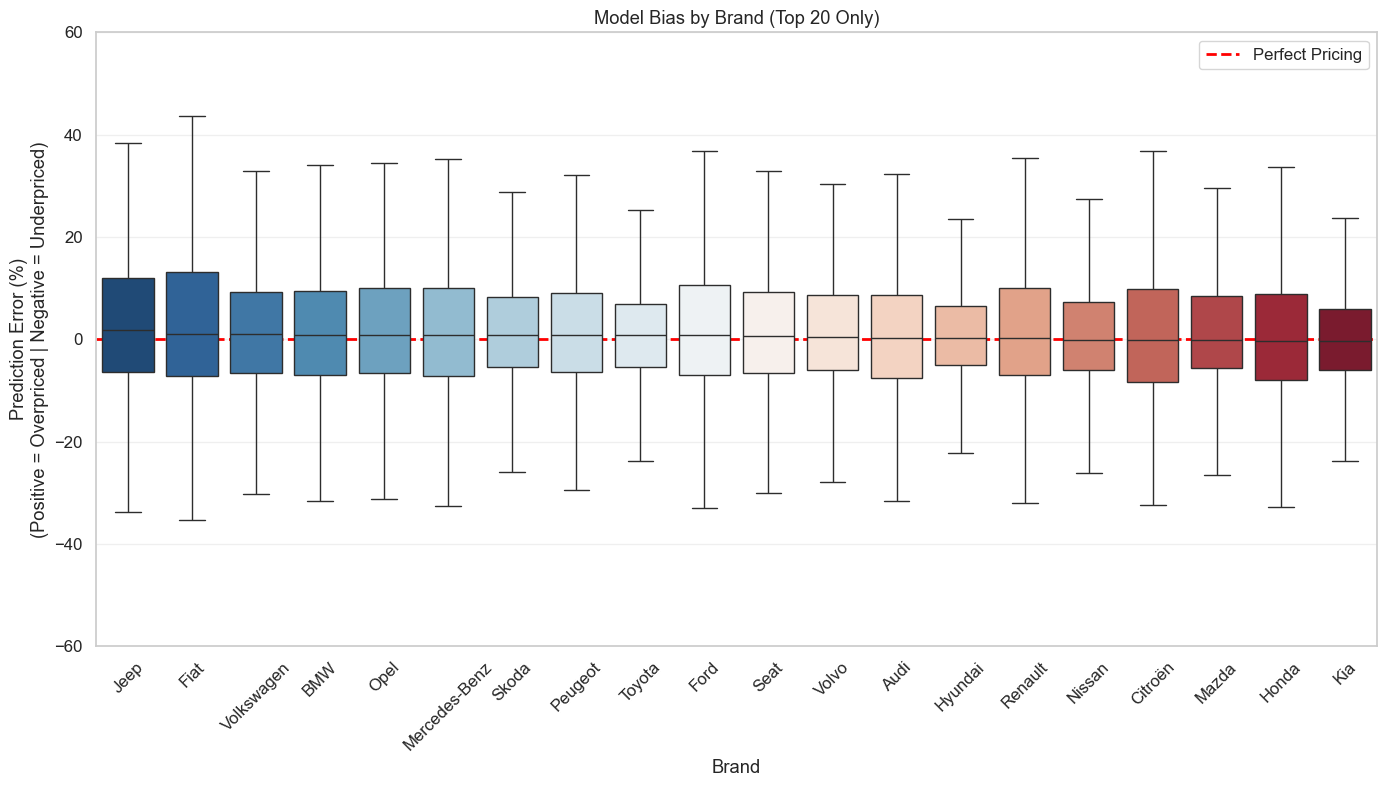

📋 BRAND BIAS TABLE (Sorted by Model Optimism)


,Volume,Median Bias (%),Mean Bias (%)
brand,,,
Jeep,550.00,1.78,5.18
Fiat,705.00,1.14,6.75
Volkswagen,3510.00,1.03,4.55
BMW,3621.00,0.95,5.08
Opel,2916.00,0.93,4.98
Mercedes-Benz,2998.00,0.93,5.95
Skoda,1934.00,0.91,4.02
Peugeot,1787.00,0.84,4.05
Toyota,2449.00,0.83,3.29


In [17]:
# --- 7.5 Brand Bias Audit: Are we fair to every badge? (Fixed) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("⚖️ Running Brand Bias Audit...")

# 1. Prepare Data
bias_df = X_holdout.copy()
bias_df['Actual_Price'] = y_holdout

if 'final_ensemble_preds' in locals():
    bias_df['Predicted_Price'] = final_ensemble_preds
else:
    bias_df['Predicted_Price'] = ag_predictor.predict(X_holdout)

# 2. Calculate "Percentage Error" (Bias)
bias_df['Pct_Error'] = ((bias_df['Predicted_Price'] - bias_df['Actual_Price']) / bias_df['Actual_Price']) * 100

# 3. Filter for Top 20 Brands
top_brands = bias_df['brand'].value_counts().nlargest(20).index
bias_analysis = bias_df[bias_df['brand'].isin(top_brands)].copy()

# --- CRITICAL FIX: Remove ghost categories ---
if bias_analysis['brand'].dtype.name == 'category':
    bias_analysis['brand'] = bias_analysis['brand'].cat.remove_unused_categories()

# 4. Sort Brands by "Median Bias"
brand_order = bias_analysis.groupby('brand')['Pct_Error'].median().sort_values(ascending=False).index

# --- VISUALIZATION ---
plt.figure(figsize=(14, 8))

# Draw Reference Line
plt.axhline(0, color='red', linestyle='--', linewidth=2, label="Perfect Pricing")

# Boxplot
sns.boxplot(
    data=bias_analysis, 
    x='brand', 
    y='Pct_Error', 
    order=brand_order, 
    palette="RdBu_r",
    showfliers=False
)

plt.title("Model Bias by Brand (Top 20 Only)")
plt.ylabel("Prediction Error (%)\n(Positive = Overpriced | Negative = Underpriced)")
plt.xlabel("Brand")
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.ylim(-60, 60)
plt.legend()
plt.tight_layout()
plt.show()

# --- SUMMARY TABLE ---
summary = bias_analysis.groupby('brand')['Pct_Error'].agg(['count', 'median', 'mean']).rename(columns={
    'count': 'Volume',
    'median': 'Median Bias (%)',
    'mean': 'Mean Bias (%)'
}).sort_values(by='Median Bias (%)', ascending=False)

print("📋 BRAND BIAS TABLE (Sorted by Model Optimism)")
display(summary.style.background_gradient(cmap='RdBu_r', subset=['Median Bias (%)', 'Mean Bias (%)']).format("{:.2f}"))

7.6 Model-Level Bias Audit (Drill Down)

In [18]:
# --- 7.6 Model-Level Bias Audit (Drill Down) ---
import pandas as pd

print("🔬 Running Deep-Dive Audit: Brand + Model Level...")

# 1. Reuse bias_df from previous step (or recreate if needed)
if 'bias_df' not in locals():
    # Quick recreate if you skipped 9.5
    bias_df = X_holdout.copy()
    bias_df['Actual_Price'] = y_holdout
    if 'final_ensemble_preds' in locals():
        bias_df['Predicted_Price'] = final_ensemble_preds
    else:
        bias_df['Predicted_Price'] = ag_predictor.predict(X_holdout)
    bias_df['Pct_Error'] = ((bias_df['Predicted_Price'] - bias_df['Actual_Price']) / bias_df['Actual_Price']) * 100

# 2. Group by Brand AND Model
model_bias = bias_df.groupby(['brand', 'model'])['Pct_Error'].agg(['count', 'median', 'mean']).rename(columns={
    'count': 'Volume',
    'median': 'Median Bias (%)',
    'mean': 'Mean Bias (%)'
})

# 3. Filter: Only models with > 50 cars in the holdout set
# This removes "noise" from rare cars (e.g. "Ford Mustang Shelby" with 1 car)
model_bias_filtered = model_bias[model_bias['Volume'] > 50].copy()

# 4. Sort: Most Overpriced (Optimistic) at the top
model_bias_sorted = model_bias_filtered.sort_values(by='Median Bias (%)', ascending=False)

# 5. Visualizing the Extremes
print(f"📋 Found {len(model_bias_sorted)} car models with Volume > 50.")
print("\n🔴 Most Overpriced (Optimistic) at the top:")
display(model_bias_sorted.head(300).style.background_gradient(cmap='RdBu_r', subset=['Median Bias (%)', 'Mean Bias (%)']).format("{:.2f}"))


# Optional: Export full list to CSV for manual review
# model_bias_sorted.to_csv("model_bias_audit.csv")

🔬 Running Deep-Dive Audit: Brand + Model Level...
📋 Found 211 car models with Volume > 50.

🔴 Most Overpriced (Optimistic) at the top:
